In [1]:
## 2026.02.11 using FineST env
## 2026.02.12 vilization cell type of each ROI
## 2026.03.04 woody_pro:: upload the HE-StarDist embedding and predict the cell type of NCRT_tumor1  
## 2026.03.06 woody_pro:: clearn code 
## 2026.03.13 update cell type level1: nanually make codex_meta_celltype_level1.csv 
## 2026.03.16 use valis to make registration [dont try]
## 2026.03.18 delete two subtypes, adjust scale factor by batch
## 2026.04.08 add plot
## 2026.04.13 Adjust the notebook as plot function, cover NCRT_train_validate_cv_plot.ipynb
## 2026.04.13 update cell type level12: nanually make codex_meta_celltype_level012.csv 

## Load anno data

In [18]:
import sys
import os
import pandas as pd
import importlib

## Add the code directory to Python path
path = '/home/lingyu/ssd2/Python/'
code_dir = f'{path}Hist2Pheno/code/Hist2Pheno_pkg/'
if code_dir not in sys.path:
    sys.path.insert(0, code_dir)

## Import (or reload) base module
import base
import plot
## Impost：Force reload base.py
importlib.reload(base)  
importlib.reload(plot)  

## Re-import the function (otherwise, still be old_version).
from base import (
    get_celltype_coords,
    divide_into_rois_by_parent,
    get_pixel_size,
    visualize_roi_cells,
    visualize_all_rois_with_he,
    visualize_all_rois,
    extract_and_save_celltype_by_tumorid,
    transformation_matrix_properties,
    invert_transformation_matrix,
    align_pcf_to_he_coordinates,
    add_pixel_coords,
    verify_transformation_alignment,
    merge_coordinates,
    analyze_and_filter_classes_by_gap,
    ImprovedMLPClassifier,
    load_embeddings,
    match_embeddings,
    prepare_matched_embeddings,
    evaluate,
    create_dataloaders,
    train_model,
    CellTypeDataset,
    evaluate_and_plot_on_all_data,
    align_matrix,
    match_StarCoords2ROI,
    match_celltype2stardist,
    merge_celltype_level12,
    make_PCF2HE_alignment,
    load_cell_pixcoords, load_hist_embeddings,
    match_hist2cell_matrix,
    make_PCF2HE2StarDist_alignment,
    save_hce_validation_metrics,
    split_train_test,
    prepare_data_leave_one_group_out,
    spatial_tile_groups_for_logo,
    loader_train_test,
)

from plot import (
    plot_celltype_distribution,
    visualize_all_celltype_distributions,
    plot_celltype_distribution,
    plot_celltype_spatial_distribution,
    plot_PCF_HE_counts,
    plot_WSI_counts,
    plot_WSI_counts_cor,
    plot_celltype_spatial_distribution,
    plot_cell_area_histogram,
    plot_confusion_matrix,
    plot_per_class_f1,
    plot_sunburst,
    plot_cell_area_histogram_zoom,
    plot_per_class_accuracy,
    plot_level1_accuracy_from_level2_predictions,
)

from model import (
    build_mlp_classifier,
    get_best_checkpoint_path,
    train_and_save_model,
    infer_input_dim_and_num_classes,
    mode_validation,
    load_model_for_predict,
    train_and_save_model_from_split,
    mode_validation_from_split,
    train_hce_leave_one_group_out_cv,
    run_logo_cv_and_load_best_model,
    report_logo_cv_means_and_insample_eval,
    run_logo_cv_with_insample_report,
)

## Import HAS_OPENSLIDE and HAS_TIFFFILE from base module for use in notebook
HAS_OPENSLIDE = base.HAS_OPENSLIDE
HAS_TIFFFILE = base.HAS_TIFFFILE

## Also import openslide module if available (needed for direct use in some cells)
if HAS_OPENSLIDE:
    import openslide
else:
    openslide = None

try:
    import tifffile
except ImportError:
    tifffile = None

print("Successfully reloaded functions")
print(f"openslide: {HAS_OPENSLIDE}, tifffile: {HAS_TIFFFILE}")


## reset pathway
os.chdir(f'{path}Hist2Pheno/data/CODEX/ESCC')
therapy_data = 'NCRT'
therapy_model = f'{therapy_data}_project_all'
segment_data1 = f'{therapy_data}_project - seg 1-14'
segment_data2 = f'{therapy_data}_project - seg 15-28'
export_data = 'export'
save_result = 'result'

stardist_data = 'StarDist_Segment'
transfer_data = 'he_cell_coords'
qupath_corner = 'QupathCorners'

Successfully reloaded functions
openslide: False, tifffile: True


## Load mete data

In [4]:
celltype_level2_path = f'{path}Hist2Pheno/data/CODEX/ESCC/codex_meta_celltype.csv'
celltype_level1_path = f'{path}Hist2Pheno/data/CODEX/ESCC/codex_meta_celltype_level1.csv'
celltype_anno_path = f'{path}Hist2Pheno/data/CODEX/ESCC/codex_meta_celltype_final.csv'
# celltype_anno_df = merge_celltype_level12(celltype_level1_path, celltype_level2_path, celltype_anno_path, run=True)
celltype_anno_df = merge_celltype_level12(celltype_level1_path, celltype_level2_path, celltype_anno_path, run=False)
celltype_anno_df.head()

The number of cells: 10893249
[merge_celltype_level12] TumorID normalized: A_* / S_* -> SA_* before save
Celltype annotation DataFrame saved to /home/lingyu/ssd2/Python/Collaborate/esccAI/data/codex_meta_celltype_finaltest.csv
The number of cells after deleting 'Low_quality' and 'non_specific' cells: 10365126
The number of cell types level2: 40
The number of cell types level1: 7


,Unnamed: 0,CellID,TumorID,celltype,celltype_level1
0,S_1,38b0fa79-483d-4a28-be51-50967be5dcdb,SA_tumor2,Treg,CD4+T
1,S_2,cd3415e0-f771-41aa-8691-8ba7c8bd0622,SA_tumor2,Bn,B
2,S_3,f7fa5bf3-e070-423c-8012-2ac7e066f456,SA_tumor2,B_other,B
3,S_4,3e7ca82c-4f00-474d-b74c-5db5abf42dd7,SA_tumor2,B_other,B
4,S_5,a6beba40-b49e-4597-ab1a-8d1f2061163a,SA_tumor2,B_other,B


In [ ]:
# The number of cells: 10893249
# [merge_celltype_level12] TumorID normalized: A_* / S_* -> SA_* before save
# Celltype annotation DataFrame saved to /home/lingyu/ssd2/Python/Hist2Pheno/data/CODEX/ESCC/codex_meta_celltype_finaltest.csv
# The number of cells after deleting 'Low_quality' and 'non_specific' cells: 10365126
# The number of cell types level2: 40
# The number of cell types level1: 7

In [3]:
## 2026.04.13 update cell type level12: nanually make codex_meta_celltype_level012.csv 
celltype_level2_path = f'{path}Hist2Pheno/data/CODEX/ESCC/codex_meta_celltype.csv'
celltype_level1_path = f'{path}Hist2Pheno/data/CODEX/ESCC/codex_meta_celltype_level1.csv'
celltype_level012_path = f'{path}Hist2Pheno/data/CODEX/ESCC/codex_meta_celltype_level012.csv'  
celltype_anno012_path = f'{path}Hist2Pheno/data/CODEX/ESCC/codex_meta_celltype_final012.csv'
celltype_anno_df = merge_celltype_level12(celltype_level012_path, celltype_level2_path, celltype_anno012_path, run=True)
# celltype_anno_df = merge_celltype_level12(celltype_level012_path, celltype_level2_path, celltype_anno012_path, run=False)
celltype_anno_df.head()

level1_meta_cols: ['celltype_level0', 'celltype_level01', 'celltype_level1', 'celltype_level12']
level1_merge_cols: ['celltype', 'celltype_level0', 'celltype_level01', 'celltype_level1', 'celltype_level12']
The number of cells: 10893249
[merge_celltype_level12] TumorID normalized: A_* / S_* -> SA_* before save
Celltype annotation DataFrame saved to /home/lingyu/ssd2/Python/Collaborate/esccAI/data/codex_meta_celltype_final012.csv
The number of cells after deleting 'Low_quality' and 'non_specific' cells: 10365126
The number of cell types level2: 40
The number of cell types level1: 7


,Unnamed: 0,CellID,TumorID,celltype,celltype_level0,celltype_level01,celltype_level1,celltype_level12
0,S_1,38b0fa79-483d-4a28-be51-50967be5dcdb,SA_tumor2,Treg,Immune,T,CD4+T,CD4_Treg
1,S_2,cd3415e0-f771-41aa-8691-8ba7c8bd0622,SA_tumor2,Bn,Immune,B,B,B_other
2,S_3,f7fa5bf3-e070-423c-8012-2ac7e066f456,SA_tumor2,B_other,Immune,B,B,B_other
3,S_4,3e7ca82c-4f00-474d-b74c-5db5abf42dd7,SA_tumor2,B_other,Immune,B,B,B_other
4,S_5,a6beba40-b49e-4597-ab1a-8d1f2061163a,SA_tumor2,B_other,Immune,B,B,B_other


level1_meta_cols: ['celltype_level0', 'celltype_level01', 'celltype_level1', 'celltype_level12']
level1_merge_cols: ['celltype', 'celltype_level0', 'celltype_level01', 'celltype_level1', 'celltype_level12']
The number of cells: 10893249
[merge_celltype_level12] TumorID normalized: A_* / S_* -> SA_* before save
Celltype annotation DataFrame saved to /home/lingyu/ssd2/Python/Hist2Pheno/data/CODEX/ESCC/codex_meta_celltype_final012.csv
The number of cells after deleting 'Low_quality' and 'non_specific' cells: 10365126
The number of cell types level2: 40
The number of cell types level1: 7

### Load groundtruth

In [4]:
# Count samples by therapy prefix from TumorID (omit suffix like _tumor1/_tumor2/...)
# Expected groups: AS, NCRT, NICT, NCT
import re

if "celltype_anno_df" not in globals() or "TumorID" not in celltype_anno_df.columns:
    raise ValueError("celltype_anno_df with column 'TumorID' is required. Run the GT loading cell first.")

tumor_base = (
    celltype_anno_df["TumorID"]
    .astype(str)
    .str.replace(r"_tumor\d+$", "", regex=True)
)

# Keep only requested categories in a fixed order
order = ["SA", "NCRT", "NICT", "NCT", "NICRT"]
count_df = (
    tumor_base.value_counts()
    .reindex(order, fill_value=0)
    .rename_axis("Therapy")
    .reset_index(name="Count")
)

display(count_df)
print("Total counted:", int(count_df["Count"].sum()))

,Therapy,Count
0,SA,2624686
1,NCRT,1746948
2,NICT,2173374
3,NCT,2327271
4,NICRT,1492847


Total counted: 10365126


### Herichical cell type anntation 

In [13]:
# celltype12_df = pd.read_csv(f'{path}Hist2Pheno/data/CODEX/ESCC/codex_meta_celltype_level1.csv')
celltype12_df = pd.read_csv(f'{path}Hist2Pheno/data/CODEX/ESCC/codex_meta_celltype_level012.csv')
celltype12_df.head()

,celltype_level0,celltype_level01,celltype_level1,celltype_level12,celltype,celltype_name
0,Immune,B,B,B_other,Bn,Naive B cell
1,Immune,B,B,B_other,Bm_switched,class-switched memory B cell
2,Immune,B,B,B_other,Bm_unswitched,class-unswitched memory B cell
3,Immune,B,B,B_other,B_proliferating,Proliferating B cell
4,Immune,B,B,B_other,B_other,CD20+B cell


In [14]:
list(celltype12_df['celltype_level1'].unique())

['B', 'CD4+T', 'CD8+T', 'Stromal', 'Myeloid', 'Tumor', 'Epithelial']

In [15]:
import numpy as np
np.array(celltype12_df['celltype'].unique())

array(['Bn', 'Bm_switched', 'Bm_unswitched', 'B_proliferating', 'B_other',
       'Plasma', 'CD4_Tn', 'CD4_Tcm', 'CD4_Tem', 'CD4_Tex', 'Treg',
       'Tfh_CXCL13', 'Tfh_CXCR5', 'Tfh_CXCL13_CXCR5', 'Th17', 'CD8_Tn',
       'CD8_Tem', 'CD8_Teff', 'CD8_Tpex', 'CD8_Tex', 'CD8_Trm',
       'CD8_Trm_ex', 'Muscle&mCAF', 'HEV', 'Endothelial', 'CAF_ap',
       'CAF_other', 'Macro_M1', 'Macro_other', 'pDC', 'cDC1', 'cDC2',
       'DC_mature', 'Neutrophil', 'Monocyte', 'Tumor_PDL1pos_MHCIpos',
       'Tumor_PDL1pos_MHCIneg', 'Tumor_PDL1neg_MHCIpos',
       'Tumor_PDL1neg_MHCIneg', 'Epithelial'], dtype=object)

In [17]:
np.array(celltype12_df['celltype_level01'].unique())

array(['B', 'T', 'Stromal', 'Myeloid', 'Tumor', 'Epithelial'],
      dtype=object)

## Plot

### Sun plot

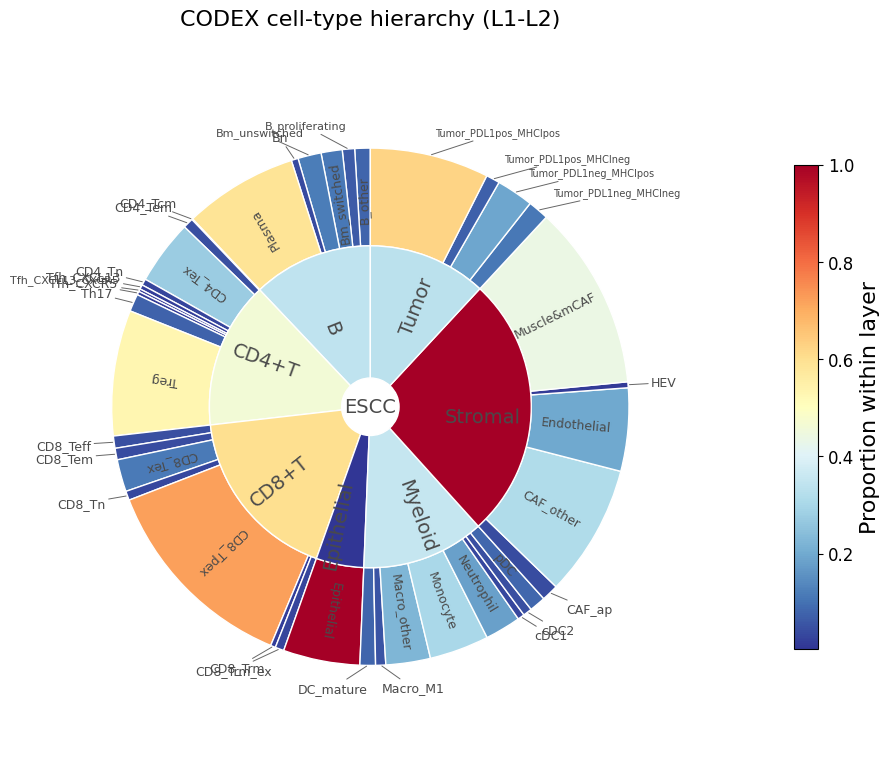

In [15]:
plot_sunburst(celltype_anno_df, scale_factor=1.2,
                fig_title="CODEX cell-type hierarchy (L1-L2)",
                save_path=None)
                # save_path=f'{path}Hist2Pheno/data/CODEX/ESCC/codex_celltype/codex_hierarchy.pdf')

### Barplot of cell type

In [6]:
celltype_coords_df1 = pd.read_csv(f'{therapy_data}/{segment_data1}/{export_data}/{therapy_data}-measurements-tumor1-14.csv')
celltype_coords_df2 = pd.read_csv(f'{therapy_data}/{segment_data2}/{export_data}/{therapy_data}-measurements-tumor-15-28.csv')
celltype_coords_df = pd.concat([celltype_coords_df1, celltype_coords_df2], ignore_index=True)
print("Cell numbers of 1-14:", celltype_coords_df1.shape)
print("Cell numbers of 15-28:", celltype_coords_df2.shape)
print("Cell numbers of 1-28:", celltype_coords_df.shape)
celltype_coords_df.head()

Cell numbers of 1-14: (870924, 58)
Cell numbers of 15-28: (1021484, 58)
Cell numbers of 1-28: (1892408, 58)


,Image,Object ID,Name,Class,Parent,ROI,Centroid X µm,Centroid Y µm,Detection probability,Nucleus: Area µm^2,...,PD-1: Cell: Mean,CD14: Cell: Mean,CD27: Cell: Mean,CD123: Cell: Mean,Granzyme B: Cell: Mean,c-PARP: Nucleus: Mean,CD38: Cell: Mean,LAG3: Cell: Mean,TCF-1: Nucleus: Mean,PD-L1: Cell: Mean
0,NCRT PCF.qptiff - resolution #1,e071bc4e-01bc-4831-a466-25be5330e3df,PathCellObject,NaN,tumor1,Polygon,4159.0,1.242,0.5100,3.9411,...,198.2059,188.0294,13.0588,12.4118,0.0000,1.6875,0.0000,33.8529,144.6875,33.2647
1,NCRT PCF.qptiff - resolution #1,99103727-0736-484a-93b0-f83efe823c03,PathCellObject,NaN,tumor1,Polygon,3970.5,2.817,0.8954,12.8580,...,198.8849,902.8584,39.9646,61.3628,0.1947,42.9184,7.4248,91.5575,178.2857,102.2389
2,NCRT PCF.qptiff - resolution #1,4882bef1-7690-443b-8e2c-512d3e81c77b,PathCellObject,NaN,tumor1,Polygon,4027.5,2.793,0.8912,30.7944,...,151.2155,2110.7844,15.8190,24.5216,0.0000,12.0635,0.3405,82.9138,138.8651,39.8319
3,NCRT PCF.qptiff - resolution #1,1e0d319a-d7c0-4c2a-85d1-08cfc6e42523,PathCellObject,NaN,tumor1,Polygon,4172.1,3.086,0.8751,28.3653,...,41.6081,88.2297,58.7523,6.5405,0.0000,1.8509,0.1171,22.0045,35.0351,11.9595
4,NCRT PCF.qptiff - resolution #1,ff987357-f306-42ab-8e03-233ac4f5e850,PathCellObject,NaN,tumor1,Polygon,3996.6,3.635,0.6372,30.5691,...,79.1639,1005.8992,7.1471,5.0840,0.0000,1.4878,0.0000,85.4328,33.2439,17.2185


In [7]:
print("The number of ROIs", len(celltype_anno_df['TumorID'].unique()))
celltype_NCRT_tumor1 = celltype_anno_df[celltype_anno_df['TumorID'] == 'NCRT_tumor1']
print("The number of cells in NCRT_tumor1", celltype_NCRT_tumor1.shape[0])
celltype_NCRT_tumor1.head()

The number of ROIs 140
The number of cells in NCRT_tumor1 80303


,Unnamed: 0,CellID,TumorID,celltype,celltype_level0,celltype_level01,celltype_level1,celltype_level12
5128939,NCRT_1,e071bc4e-01bc-4831-a466-25be5330e3df,NCRT_tumor1,CAF_other,Stromal,Stromal,Stromal,Stromal_other
5128940,NCRT_2,99103727-0736-484a-93b0-f83efe823c03,NCRT_tumor1,Neutrophil,Immune,Myeloid,Myeloid,Myeloid_other
5128941,NCRT_3,4882bef1-7690-443b-8e2c-512d3e81c77b,NCRT_tumor1,Monocyte,Immune,Myeloid,Myeloid,Myeloid_other
5128942,NCRT_4,1e0d319a-d7c0-4c2a-85d1-08cfc6e42523,NCRT_tumor1,CAF_other,Stromal,Stromal,Stromal,Stromal_other
5128943,NCRT_5,ff987357-f306-42ab-8e03-233ac4f5e850,NCRT_tumor1,Monocyte,Immune,Myeloid,Myeloid,Myeloid_other


In [19]:
# ## Call the function to batch visualize all folders
# visualize_all_celltype_distributions(base_path=f'{path}Hist2Pheno/data/CODEX/ESCC/codex_celltype')

The number of cells in celltype: 10365126
The distribution of celltype: celltype
CD8_Tpex                 1329760
Muscle&mCAF              1197496
CAF_other                 853404
Treg                      813448
Tumor_PDL1pos_MHCIpos     770217
Plasma                    738198
Endothelial               537909
Epithelial                496437
CD4_Tex                   418058
Monocyte                  385513
Macro_other               288451
Tumor_PDL1neg_MHCIpos     239810
Neutrophil                231752
CD8_Tex                   208595
Bm_unswitched             150591
Bm_switched               136771
Tumor_PDL1neg_MHCIneg     135267
Th17                      113394
CAF_ap                    109152
pDC                       105455
DC_mature                 100480
B_other                   100161
Tumor_PDL1pos_MHCIneg      88774
B_proliferating            79780
CD8_Teff                   79152
CD8_Tem                    74785
CD4_Tem                    67175
Macro_M1                   6

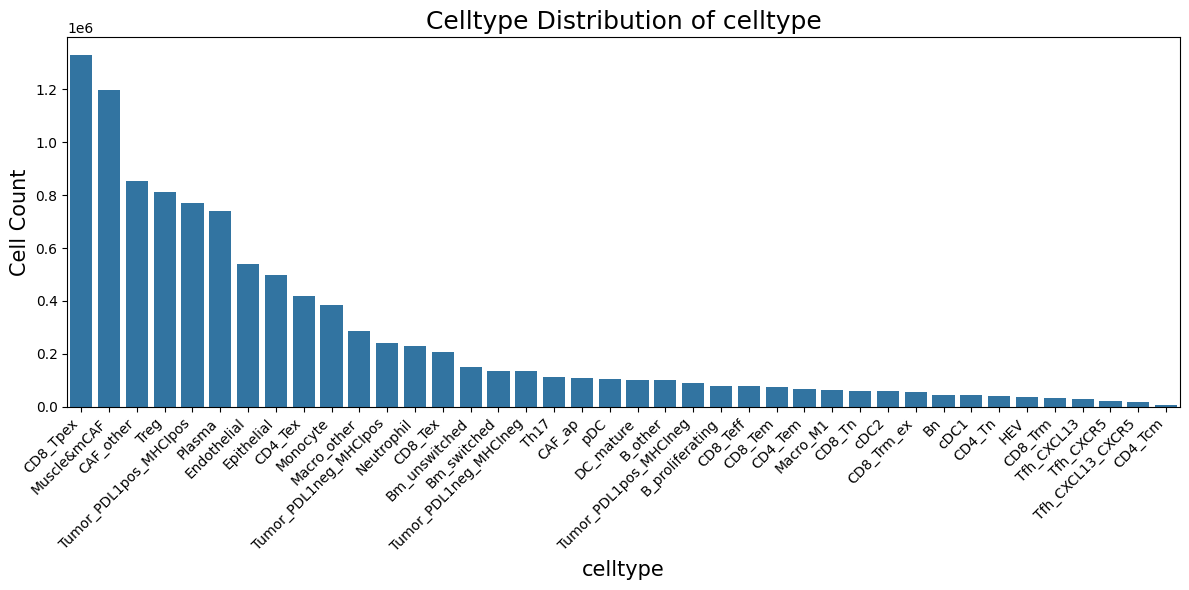

The number of cells in celltype_level1: 10365126
The distribution of celltype_level1: celltype_level1
Stromal       2736176
CD8+T         1840623
CD4+T         1528471
Myeloid       1279134
B             1250217
Tumor         1234068
Epithelial     496437
Name: count, dtype: int64


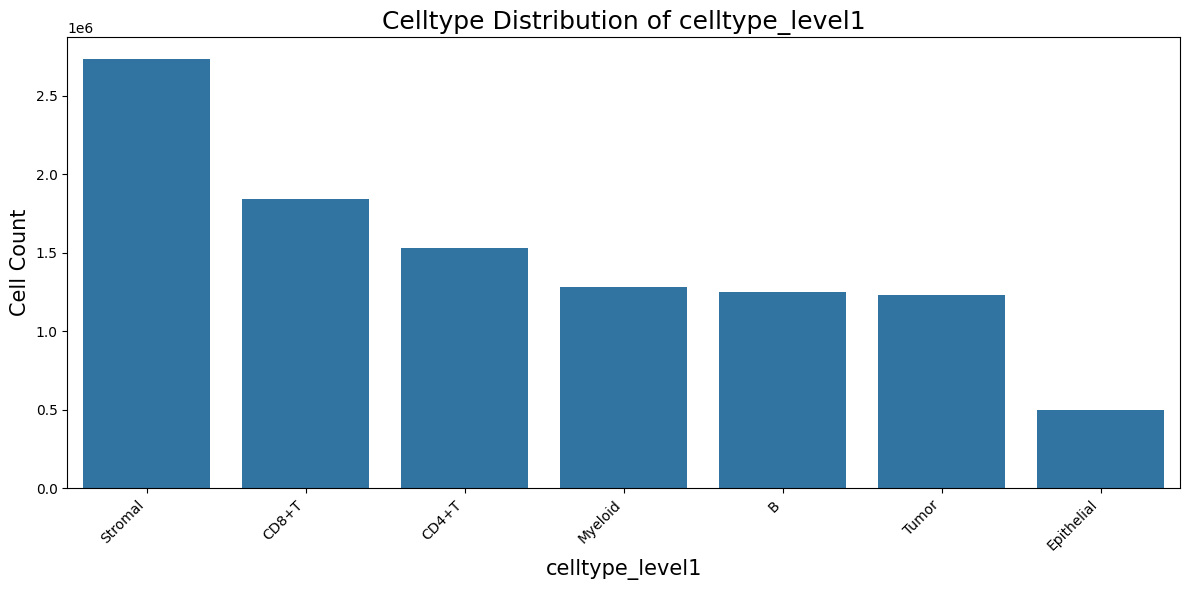

In [20]:
plot_celltype_distribution(celltype_anno_df, 
                            celltype_col='celltype',
                            save_path=None)
                            # save_path=f'{therapy_data}/{save_result}/celltype_dist_level2.pdf')

plot_celltype_distribution(celltype_anno_df, 
                            celltype_col='celltype_level1',
                            save_path=None)
                            # save_path=f'{therapy_data}/{save_result}/celltype_dist_level1.pdf')

The number of cells in celltype_level0: 10365126
The distribution of celltype_level0: celltype_level0
Immune        5898445
Stromal       2736176
Tumor         1234068
Epithelial     496437
Name: count, dtype: int64


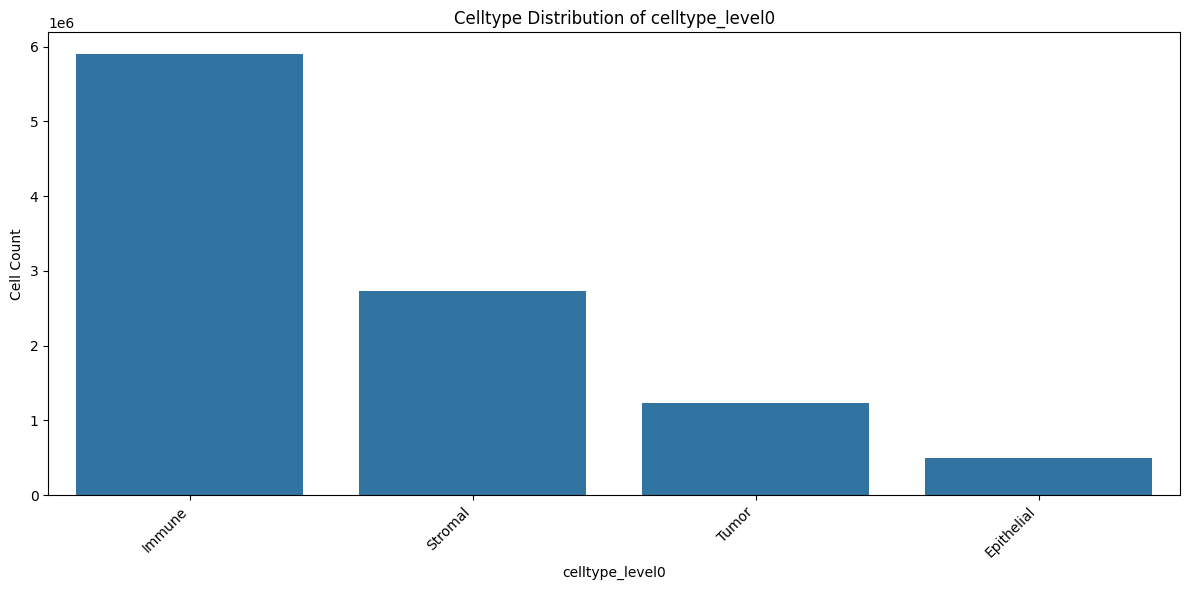

The number of cells in celltype_level01: 10365126
The distribution of celltype_level01: celltype_level01
T             3369094
Stromal       2736176
Myeloid       1279134
B             1250217
Tumor         1234068
Epithelial     496437
Name: count, dtype: int64


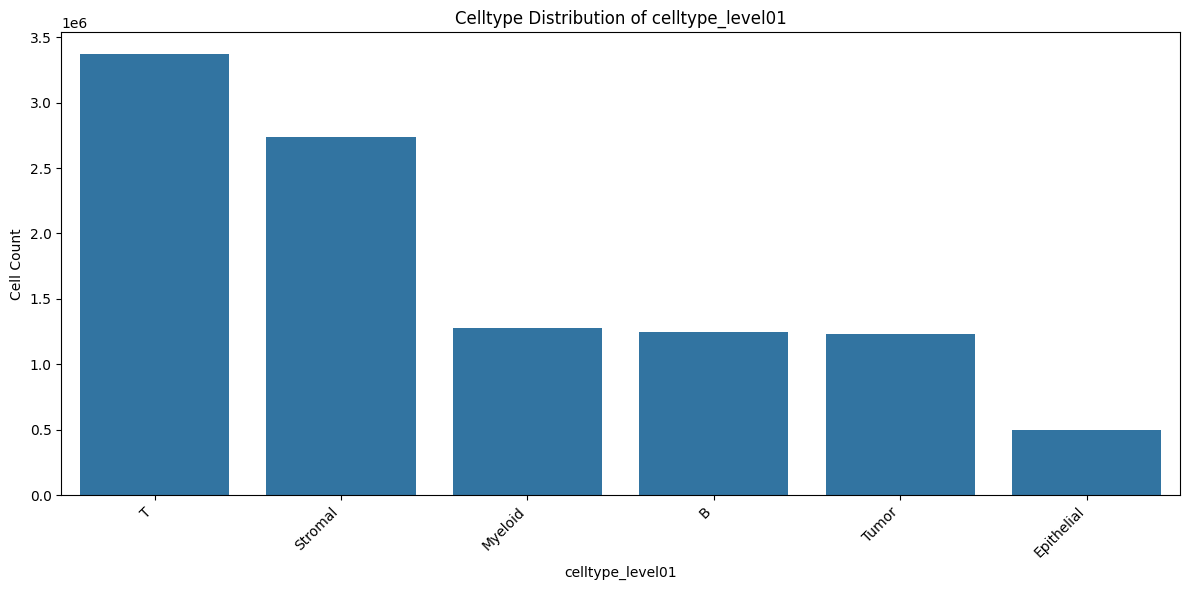

The number of cells in celltype_level12: 10365126
The distribution of celltype_level12: celltype_level12
Stromal_other    2736176
CD8_Other        1761471
Tumor            1234068
CD4_Treg          813448
B_plasma          738198
CD4_Tconv         715023
Myeloid_other     617265
B_other           512019
Epithelial        496437
Macrophage        353896
Dendritic         307973
CD8_Effector       79152
Name: count, dtype: int64


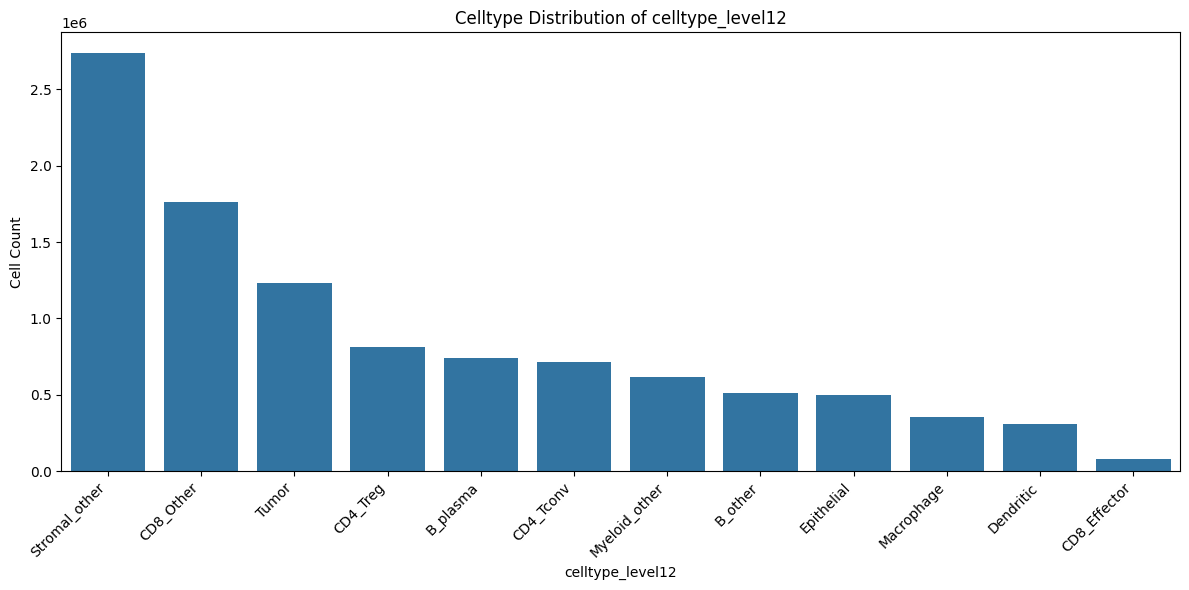

In [8]:
plot_celltype_distribution(celltype_anno_df, 
                            celltype_col='celltype_level0',
                            save_path=None)
                            # save_path=f'{therapy_data}/{save_result}/celltype_dist_level2.pdf')

plot_celltype_distribution(celltype_anno_df, 
                            celltype_col='celltype_level01',
                            save_path=None)
                            # save_path=f'{therapy_data}/{save_result}/celltype_dist_level2.pdf')

plot_celltype_distribution(celltype_anno_df, 
                            celltype_col='celltype_level12',
                            save_path=None)
                            # save_path=f'{therapy_data}/{save_result}/celltype_dist_level1.pdf')

The number of cells in celltype: 80303
The distribution of celltype: celltype
Epithelial               16508
Muscle&mCAF               7372
Plasma                    6308
CD8_Tpex                  5978
Monocyte                  4767
Treg                      4520
CAF_other                 4181
Tumor_PDL1pos_MHCIpos     3801
Tumor_PDL1neg_MHCIpos     3526
Macro_other               3355
Neutrophil                3075
Endothelial               2881
CD4_Tex                   2502
CD8_Tex                   2310
Tumor_PDL1neg_MHCIneg     2263
Macro_M1                  1023
DC_mature                  747
pDC                        738
CD8_Teff                   723
CD8_Trm_ex                 444
B_other                    426
Bm_switched                376
Bm_unswitched              354
cDC2                       294
CD4_Tem                    274
CAF_ap                     223
cDC1                       219
Th17                       200
CD8_Tn                     165
Tfh_CXCL13_CXCR5       

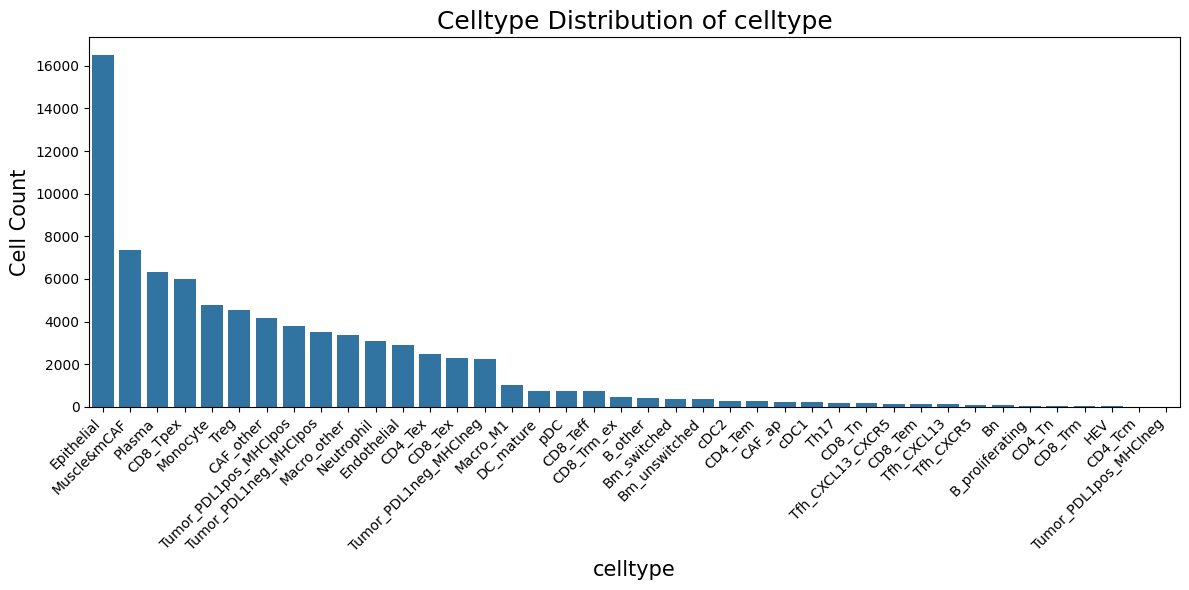

The number of cells in celltype_level1: 80303
The distribution of celltype_level1: celltype_level1
Epithelial    16508
Stromal       14692
Myeloid       14218
CD8+T          9815
Tumor          9591
CD4+T          7887
B              7592
Name: count, dtype: int64


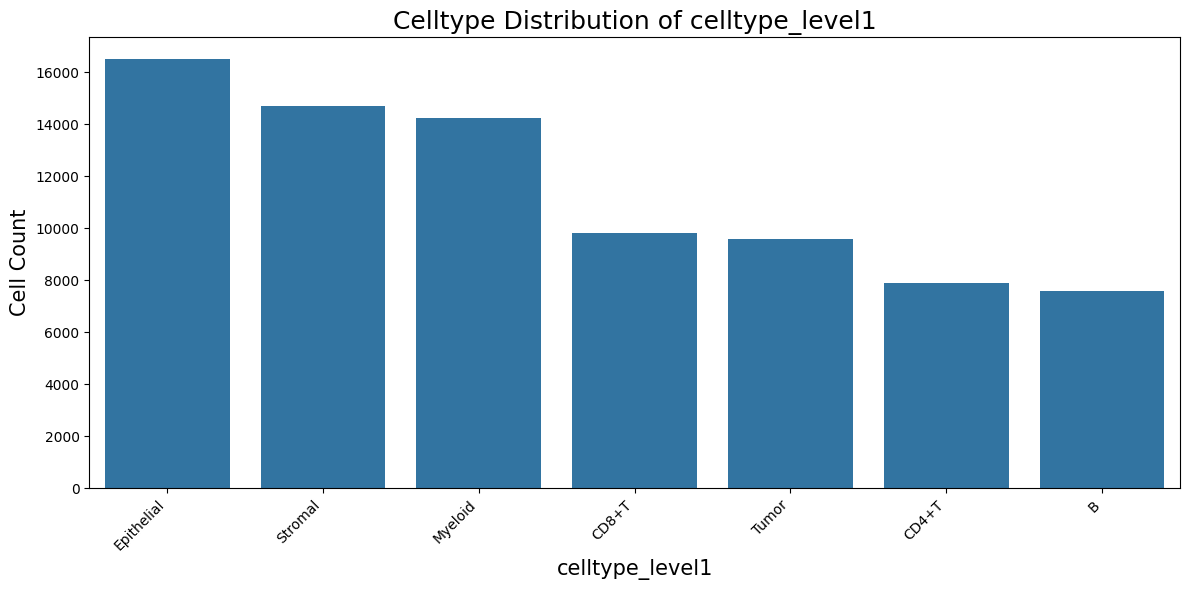

In [21]:
plot_celltype_distribution(celltype_NCRT_tumor1, 
                            celltype_col='celltype',
                            save_path=None)
                            # save_path=f'{therapy_data}/{save_result}/celltype_dist_tumor1_level2.pdf')

plot_celltype_distribution(celltype_NCRT_tumor1, 
                            celltype_col='celltype_level1',
                            save_path=None)
                            # save_path=f'{therapy_data}/{save_result}/celltype_dist_tumor1_level1.pdf')

### Cell area histogram

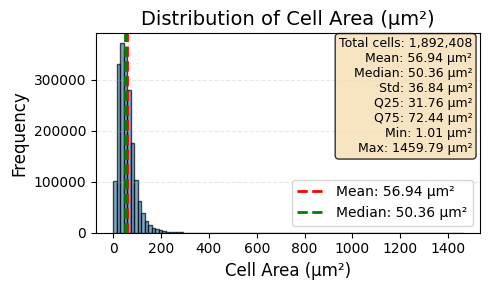


Summary Statistics for 'Cell: Area µm^2':
  Total cells: 1,892,408
  Mean: 56.94 µm²
  Median: 50.36 µm²
  Standard deviation: 36.84 µm²
  Range: [1.01, 1459.79] µm²
  IQR: [31.76, 72.44] µm²


In [22]:
# plot_cell_area_histogram(celltype_coords_df1, 
#                         save_path=None)
                        # save_path=f'{therapy_data}/{save_result}/cellarea_dist_1_14.pdf')
# plot_cell_area_histogram(celltype_coords_df2, 
#                         save_path=None)
                        # save_path=f'{therapy_data}/{save_result}/cellarea_dist_15_28.pdf')
plot_cell_area_histogram(celltype_coords_df, figsize=(5,3),
                        save_path=None)
                        # save_path=f'{therapy_data}/{save_result}/cellarea_dist_ismb.pdf')

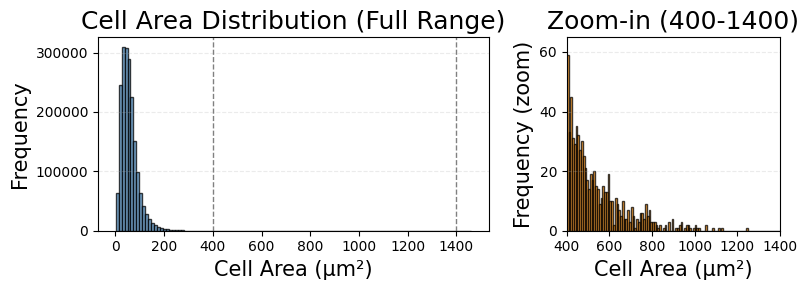

In [24]:
plot_cell_area_histogram_zoom(
    celltype_coords_df,
    figsize=(8, 3),
    zoom_xlim=(400, 1400),
    # save_path=f'{therapy_data}/{save_result}/cellarea_dist_ismb_zoom.pdf',
    save_path=None
)

In [10]:
## celltype_NCRT_tumor1
celltype_NCRT_tumor1 = get_celltype_coords(celltype_anno_df, celltype_coords_df, value='NCRT_tumor1', parent_value='tumor1')
celltype_NCRT_tumor1.head()

['Unnamed: 0', 'CellID', 'TumorID', 'celltype', 'celltype_level0', 'celltype_level01', 'celltype_level1', 'celltype_level12']
Before filtering - ncrt_anno_df1 shape: (1892408, 58)
Unique Parent values:
 ['tumor1' 'tumor2' 'tumor3' 'tumor4' 'tumor5' 'tumor6' 'tumor7' 'tumor8'
 'tumor9' 'tumor10' 'tumor11' 'tumor12' 'tumor13' 'tumor14' 'tumor15'
 'tumor16' 'tumor17' 'tumor18' 'tumor19' 'tumor20' 'tumor21' 'tumor22'
 'tumor23' 'tumor24' 'tumor25' 'tumor26' 'tumor28' 'tumor27']
After filtering for 'tumor1' - ncrt_anno_df1_tumor1 shape: (82805, 58)
Number of cells in tumor1: 82805

Shape of celltype_NCRT_tumor1 before merging: (80303, 8)
Shape of ncrt_anno_df1_tumor1: (82805, 58)
Shape of celltype_NCRT_tumor1 after merging: (80303, 10)

Columns after merging: ['Unnamed: 0', 'CellID', 'TumorID', 'celltype', 'celltype_level0', 'celltype_level01', 'celltype_level1', 'celltype_level12', 'Centroid X µm', 'Centroid Y µm']
Successfully matched cells: 80303 / 80303 (100.00%)


,Unnamed: 0,CellID,TumorID,celltype,celltype_level0,celltype_level01,celltype_level1,celltype_level12,Centroid X µm,Centroid Y µm
0,NCRT_1,e071bc4e-01bc-4831-a466-25be5330e3df,NCRT_tumor1,CAF_other,Stromal,Stromal,Stromal,Stromal_other,4159.0,1.242
1,NCRT_2,99103727-0736-484a-93b0-f83efe823c03,NCRT_tumor1,Neutrophil,Immune,Myeloid,Myeloid,Myeloid_other,3970.5,2.817
2,NCRT_3,4882bef1-7690-443b-8e2c-512d3e81c77b,NCRT_tumor1,Monocyte,Immune,Myeloid,Myeloid,Myeloid_other,4027.5,2.793
3,NCRT_4,1e0d319a-d7c0-4c2a-85d1-08cfc6e42523,NCRT_tumor1,CAF_other,Stromal,Stromal,Stromal,Stromal_other,4172.1,3.086
4,NCRT_5,ff987357-f306-42ab-8e03-233ac4f5e850,NCRT_tumor1,Monocyte,Immune,Myeloid,Myeloid,Myeloid_other,3996.6,3.635


### Visualization CODEX tumorX

Number of valid data points: 80303
Number of cell types: 40


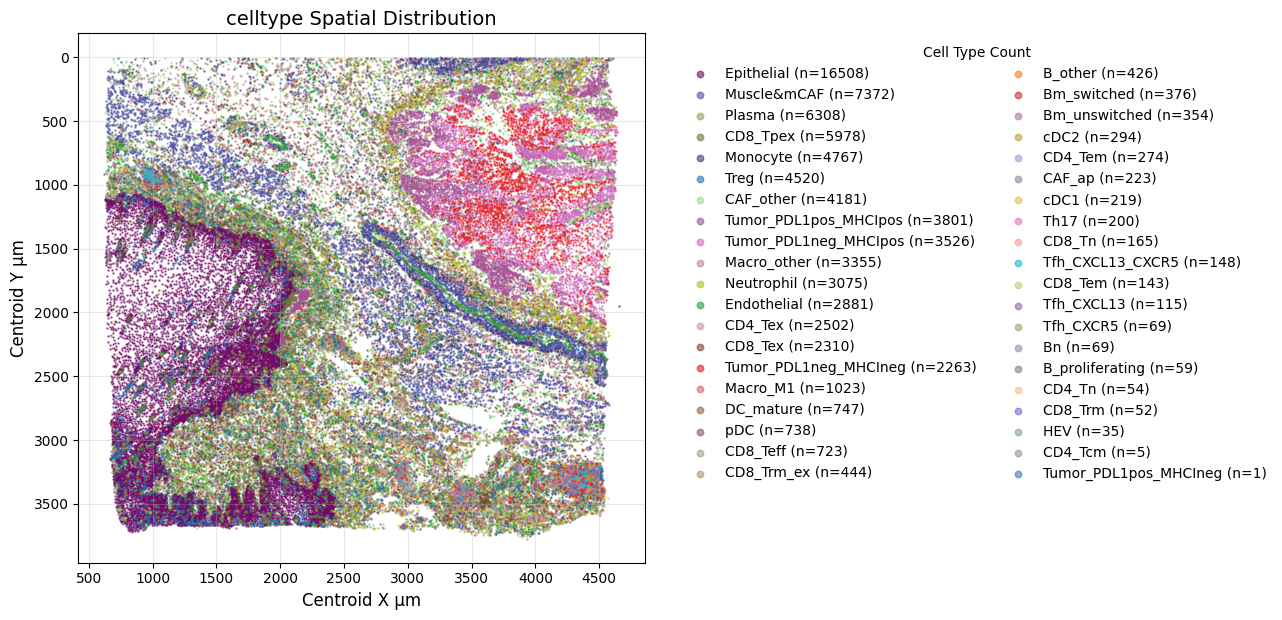

(<Figure size 1200x1000 with 1 Axes>,
 <Axes: title={'center': 'celltype Spatial Distribution'}, xlabel='Centroid X µm', ylabel='Centroid Y µm'>)

In [11]:
## Plot the spatial distribution of cell types in celltype_NCRT_tumor1
plot_celltype_spatial_distribution(celltype_NCRT_tumor1,
                                   x_col='Centroid X µm', y_col='Centroid Y µm',
                                   celltype_col='celltype',
                                   figsize=(12, 10), alpha=0.6,s=0.6,
                                    format='jpg', save_path=None)
                                    # format='jpg', save_path=f'{therapy_data}/{save_result}/celltype_spatial_tumor1_level2.jpg')

Number of valid data points: 80303
Number of cell types: 40


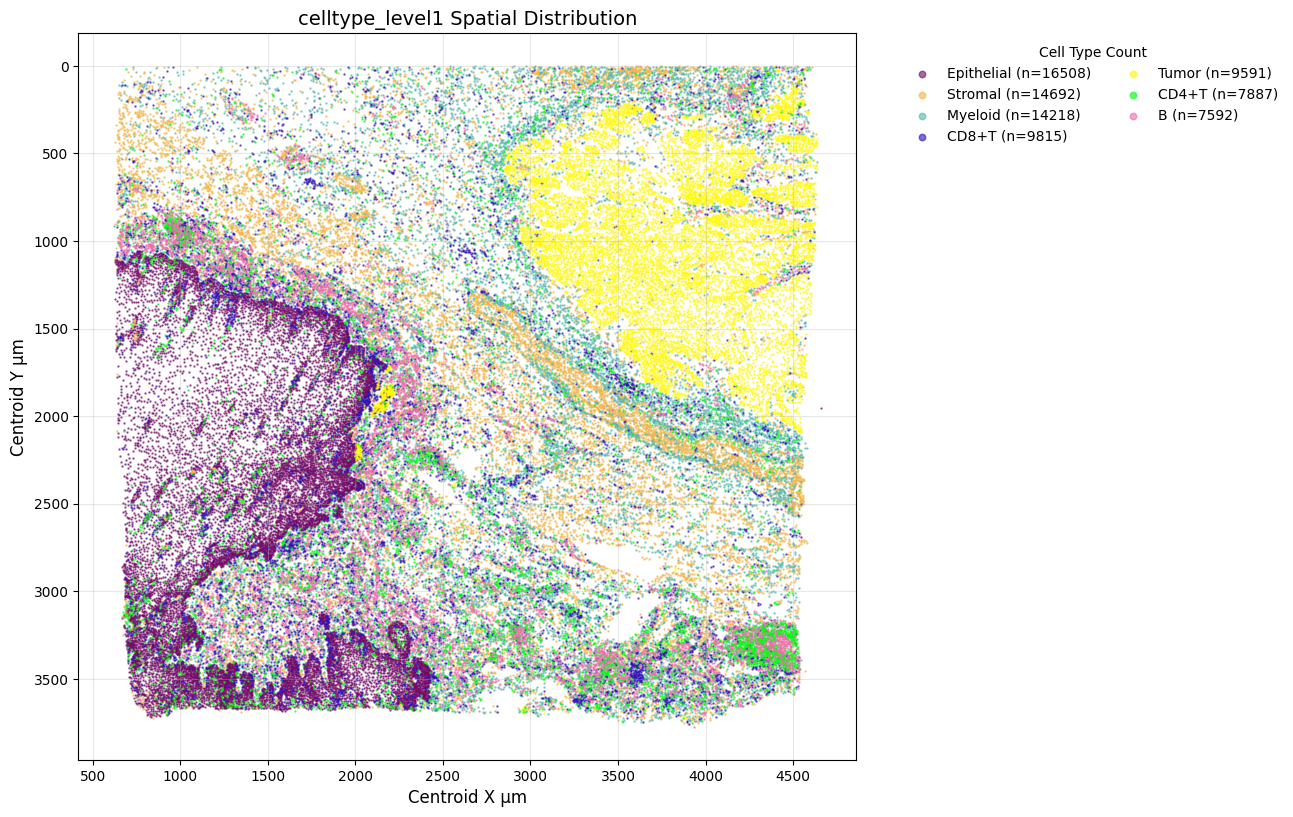

(<Figure size 1200x1000 with 1 Axes>,
 <Axes: title={'center': 'celltype_level1 Spatial Distribution'}, xlabel='Centroid X µm', ylabel='Centroid Y µm'>)

In [12]:
plot_celltype_spatial_distribution(celltype_NCRT_tumor1,
                                   x_col='Centroid X µm', y_col='Centroid Y µm',
                                   celltype_col='celltype_level1',
                                   figsize=(12, 10), alpha=0.6,s=0.6,
                                    format='jpg', save_path=None)
                                    # format='jpg', save_path=f'{therapy_data}/{save_result}/celltype_spatial_tumor1_level1.jpg')

Number of valid data points: 80303
Number of cell types: 4


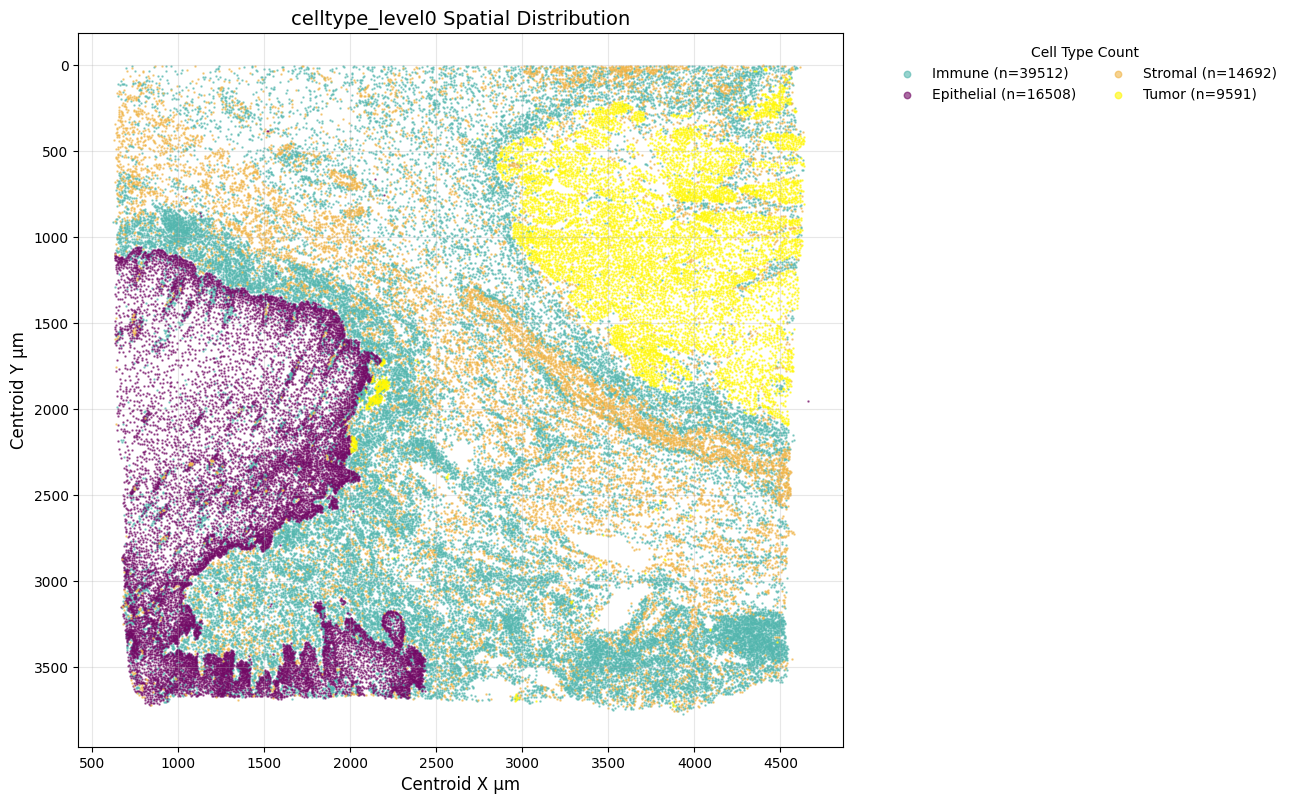

Number of valid data points: 80303
Number of cell types: 6


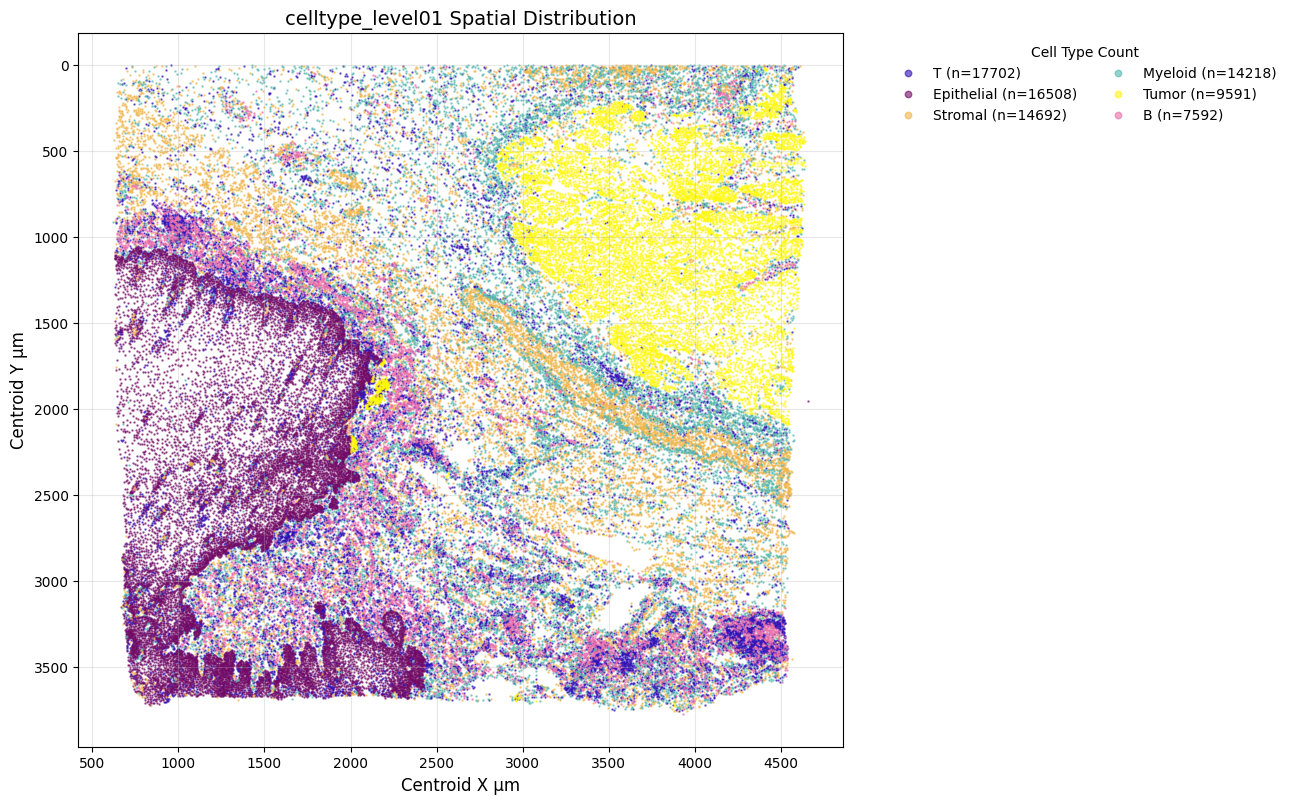

Number of valid data points: 80303
Number of cell types: 12


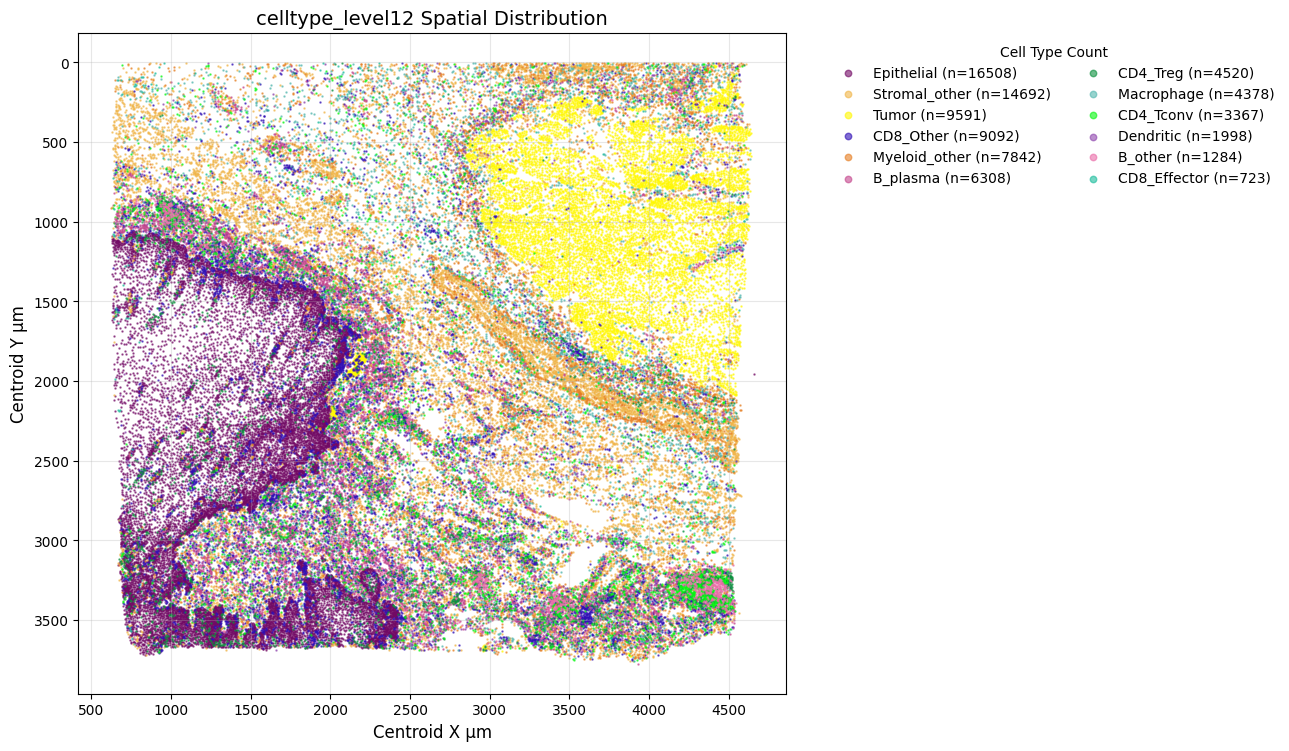

(<Figure size 1200x1000 with 1 Axes>,
 <Axes: title={'center': 'celltype_level12 Spatial Distribution'}, xlabel='Centroid X µm', ylabel='Centroid Y µm'>)

In [19]:
plot_celltype_spatial_distribution(celltype_NCRT_tumor1,
                                   x_col='Centroid X µm', y_col='Centroid Y µm',
                                   celltype_col='celltype_level0',
                                   figsize=(12, 10), alpha=0.6,s=0.6,
                                    format='jpg', save_path=None)
                                    # format='jpg', save_path=f'{therapy_data}/{save_result}/celltype_spatial_tumor1_level1.jpg')

plot_celltype_spatial_distribution(celltype_NCRT_tumor1,
                                   x_col='Centroid X µm', y_col='Centroid Y µm',
                                   celltype_col='celltype_level01',
                                   figsize=(12, 10), alpha=0.6,s=0.6,
                                    format='jpg', save_path=None)
                                    # format='jpg', save_path=f'{therapy_data}/{save_result}/celltype_spatial_tumor1_level1.jpg')

plot_celltype_spatial_distribution(celltype_NCRT_tumor1,
                                   x_col='Centroid X µm', y_col='Centroid Y µm',
                                   celltype_col='celltype_level12',
                                   figsize=(12, 10), alpha=0.6,s=0.6,
                                    format='jpg', save_path=None)
                                    # format='jpg', save_path=f'{therapy_data}/{save_result}/celltype_spatial_tumor1_level1.jpg')

In [14]:
# ## celltype_NCRT_tumor5
# celltype_NCRT_tumor5 = get_celltype_coords(celltype_anno_df, celltype_coords_df1, value='NCRT_tumor5', parent_value='tumor5')
# # celltype_NCRT_tumor5.head()
# plot_celltype_spatial_distribution(celltype_NCRT_tumor5,
#                                    x_col='Centroid X µm', y_col='Centroid Y µm',
#                                    celltype_col='celltype',
#                                    figsize=(12, 10), alpha=0.6,s=0.6,
#                                    # format='jpg', save_path=None)  
#                                     format='jpg', save_path=f'{therapy_data}/{save_result}/celltype_spatial_tumor5_level2.jpg')
# plot_celltype_spatial_distribution(celltype_NCRT_tumor5,
#                                    x_col='Centroid X µm', y_col='Centroid Y µm',
#                                    celltype_col='celltype_level1',
#                                    figsize=(12, 10), alpha=0.6,s=0.6,
#                                    # format='jpg', save_path=None)  
#                                     format='jpg', save_path=f'{therapy_data}/{save_result}/celltype_spatial_tumor5_level1.jpg')

## HE-feature validation

### Segment correlation for NCRT

'he_cell_coords'

<!-- ## Option A: Using HIPT (recommended for quick start, no token required)
python ./demo/Image_feature_extraction.py \
   --dataset NPC \
   --position_path FineST_tutorial_data/spatial/tissue_positions_list.csv \
   --rawimage_path FineST_tutorial_data/20210809-C-AH4199551.tif \
   --scale_image False \
   --method HIPT \
   --patch_size 64 \
   --output_img FineST_tutorial_data/ImgEmbeddings/pth_64_16_image \
   --output_pth FineST_tutorial_data/ImgEmbeddings/pth_64_16 \
   --logging FineST_tutorial_data/ImgEmbeddings/Logging/ \
   --scale 0.5  # default is 0.5 -->

In [28]:
## Tumor1
# stardist_coords_path = f'{path}Hist2Pheno/data/CODEX/ESCC/{stardist_data}/{therapy_data}_Float_prob0.01_nms_0.3.csv'
# qupath_corner_path = f'{path}Hist2Pheno/data/CODEX/ESCC/{qupath_corner}/{therapy_data}_ROI_Corners.csv'
# codex_meta_celltype_path = f'{path}Hist2Pheno/data/CODEX/ESCC/codex_meta_celltype_final.csv'
# celltype_pixel_NCRT_path = f'{path}Hist2Pheno/data/CODEX/ESCC/{transfer_data}/{therapy_data}_CellPixCoords.csv'
# save_path = f'{path}Hist2Pheno/data/CODEX/ESCC/he_cell_coords/{therapy_data}_CellPixCoords_tumor1_StarDist.csv'
# save_path4ViT = f'{path}Hist2Pheno/data/CODEX/ESCC/he_cell_coords/{therapy_data}_CellPixCoords_tumor1_StarDist_ViT.csv'

## All
# therapy_data = 'NCRT'
# stardist_coords_path = f'{path}Hist2Pheno/data/CODEX/ESCC/{stardist_data}/{therapy_data}_Float_prob0.01_nms_0.3.csv'
# qupath_corner_path = f'{path}Hist2Pheno/data/CODEX/ESCC/{qupath_corner}/{therapy_data}_ROI_Corners.csv'
# codex_meta_celltype_path = f'{path}Hist2Pheno/data/CODEX/ESCC/codex_meta_celltype_final.csv'
# celltype_pixel_NCRT_path = f'{path}Hist2Pheno/data/CODEX/ESCC/{transfer_data}/{therapy_data}_CellPixCoords_all.csv'
# save_path = f'{path}Hist2Pheno/data/CODEX/ESCC/{transfer_data}/{therapy_data}_CellPixCoords_all_StarDist.csv'
# save_path4ViT = f'{path}Hist2Pheno/data/CODEX/ESCC/{transfer_data}/{therapy_data}_CellPixCoords_all_StarDist_ViT.csv'

## All level012
therapy_data = 'NCRT'
transfer_data = 'he_cell_coords'
parent_value='tumor1'
stardist_coords_path = f'{path}Hist2Pheno/data/CODEX/ESCC/{stardist_data}/{therapy_data}_Float_prob0.01_nms_0.3.csv'
qupath_corner_path = f'{path}Hist2Pheno/data/CODEX/ESCC/{qupath_corner}/{therapy_data}_ROI_Corners.csv'
codex_meta_celltype_path = f'{path}Hist2Pheno/data/CODEX/ESCC/codex_meta_celltype_final012.csv'
celltype_pixel_NCRT_path = f'{path}Hist2Pheno/data/CODEX/ESCC/{transfer_data}/{therapy_data}_CellPixCoords_all.csv'
save_path = f'{path}Hist2Pheno/data/CODEX/ESCC/{transfer_data}/{therapy_data}_CellPixCoords_{parent_value}_StarDist.csv'
save_path4ViT = f'{path}Hist2Pheno/data/CODEX/ESCC/{transfer_data}/{therapy_data}_CellPixCoords_{parent_value}_StarDist_ViT.csv'

In [27]:
celltype_anno_df, roi_cell_counts, star_coords_in_roi, celltype_pixel_NCRT = make_PCF2HE2StarDist_alignment(
    stardist_coords_path,
    qupath_corner_path,
    codex_meta_celltype_path,
    celltype_pixel_NCRT_path,
    therapy_data=f'{therapy_data}',
    parent_value='all',
    save_path=save_path,
    save_path4ViT=save_path4ViT
    # save_path=None,
    # save_path4ViT=None
)

/home/lingyu/ssd2/Python/Collaborate/esccAI/code/Hist2Pheno_pkg/base.py:3539: FutureWarning: Setting an item of incompatible dtype is deprecated and will raise an error in a future version of pandas. Value 'NCRT_tumor27' has dtype incompatible with float64, please explicitly cast to a compatible dtype first.
  star_coords.loc[mask, 'TumorID'] = name


Number of rows with TumorID = NaN: 2676
star_coords shape after filtering: (2025438, 4)
       TumorID   centroid_x   centroid_y  probability
0  NCRT_tumor1  6863.988266  3320.483284     0.884281
1  NCRT_tumor1  7168.098045  1736.226154     0.878382
2  NCRT_tumor1  7189.928642  1536.107811     0.877665
3  NCRT_tumor1  7227.680878  1686.196735     0.875756
4  NCRT_tumor1  7272.088211  2399.935646     0.872943
Nuclei number within each ROI (sorted by TumorID):
         TumorID  cell_count
2    NCRT_tumor1       94963
4    NCRT_tumor2       91422
26   NCRT_tumor3       43568
18   NCRT_tumor4       65337
5    NCRT_tumor5       86115
23   NCRT_tumor6       58079
27   NCRT_tumor7       25843
25   NCRT_tumor8       53104
10   NCRT_tumor9       77542
24  NCRT_tumor10       57359
8   NCRT_tumor11       79697
9   NCRT_tumor12       79563
14  NCRT_tumor13       72766
11  NCRT_tumor14       74430
21  NCRT_tumor15       60176
20  NCRT_tumor16       61779
7   NCRT_tumor17       84053
3   NCRT_tumor1

In [ ]:
# celltype_anno_df, roi_cell_counts, star_coords_in_roi, celltype_pixel_NCRT = make_PCF2HE2StarDist_alignment(
#     stardist_coords_path,
#     qupath_corner_path,
#     codex_meta_celltype_path,
#     celltype_pixel_NCRT_path,
#     therapy_data=f'{therapy_data}',
#     parent_value='tumor1',
#     save_path=save_path,
#     save_path4ViT=save_path4ViT
#     # save_path=None,
#     # save_path4ViT=None
# )

/home/lingyu/ssd2/Python/Collaborate/esccAI/code/Hist2Pheno_pkg/base.py:3539: FutureWarning: Setting an item of incompatible dtype is deprecated and will raise an error in a future version of pandas. Value 'NCRT_tumor27' has dtype incompatible with float64, please explicitly cast to a compatible dtype first.
  star_coords.loc[mask, 'TumorID'] = name


Number of rows with TumorID = NaN: 2676
star_coords shape after filtering: (2025438, 4)
       TumorID   centroid_x   centroid_y  probability
0  NCRT_tumor1  6863.988266  3320.483284     0.884281
1  NCRT_tumor1  7168.098045  1736.226154     0.878382
2  NCRT_tumor1  7189.928642  1536.107811     0.877665
3  NCRT_tumor1  7227.680878  1686.196735     0.875756
4  NCRT_tumor1  7272.088211  2399.935646     0.872943
Nuclei number within each ROI (sorted by TumorID):
         TumorID  cell_count
2    NCRT_tumor1       94963
4    NCRT_tumor2       91422
26   NCRT_tumor3       43568
18   NCRT_tumor4       65337
5    NCRT_tumor5       86115
23   NCRT_tumor6       58079
27   NCRT_tumor7       25843
25   NCRT_tumor8       53104
10   NCRT_tumor9       77542
24  NCRT_tumor10       57359
8   NCRT_tumor11       79697
9   NCRT_tumor12       79563
14  NCRT_tumor13       72766
11  NCRT_tumor14       74430
21  NCRT_tumor15       60176
20  NCRT_tumor16       61779
7   NCRT_tumor17       84053
3   NCRT_tumor1

ROIs where orange bar (HE: cell_count) is lower than blue bar (PCF: celltype_count):
['NCRT_tumor3', 'NCRT_tumor25']


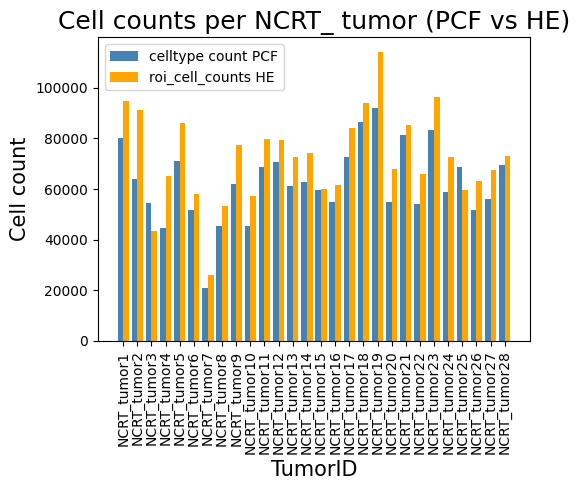

In [33]:
merged = plot_WSI_counts(celltype_anno_df, roi_cell_counts, prefix=f'{therapy_data}_', figure_size=(5.5,5),
                         save_path=None)
                        # save_path=f'{path}Hist2Pheno/data/CODEX/ESCC/{therapy_data}/{save_result}/cellcounts_compare_{therapy_data}.pdf')

NCRT_tumor3 - star_coords_in_roi shape: (43568, 4)
NCRT_tumor3 - celltype_pixel_NCRT shape: (54500, 13)


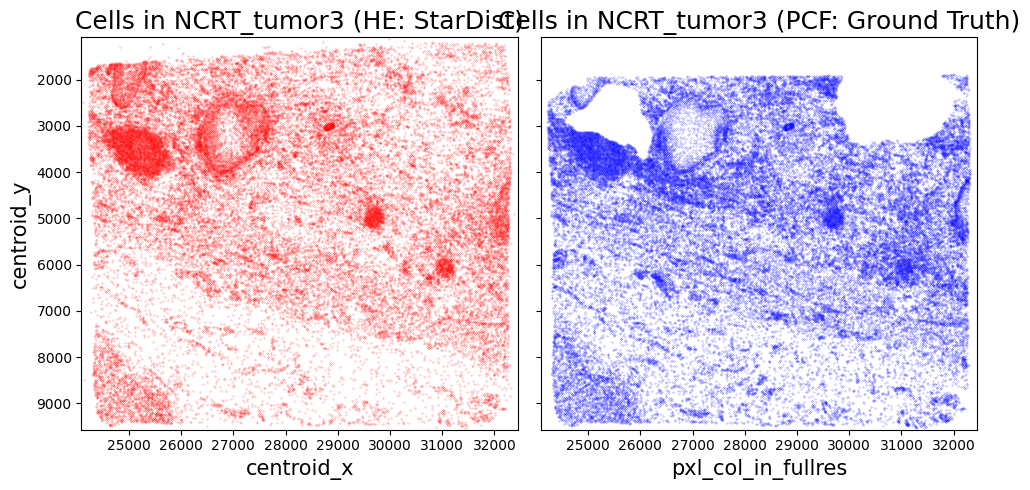

In [35]:
plot_PCF_HE_counts(star_coords_in_roi, celltype_pixel_NCRT, ROI=f'{therapy_data}_tumor3', figure_size=(10,5),
# plot_PCF_HE_counts(star_coords_in_roi, celltype_pixel_NCRT, ROI='NCRT_tumor3', figure_size=(10,5),
                    save_path=None)
                #    save_path=f'{path}Hist2Pheno/data/CODEX/ESCC/{therapy_data}/{save_result}/cellcounts_compare_tumor3.jpg')

Tumor count used: 28
Pearson r = 0.8976, p = 9.611e-11
Spearman rho = 0.8801, p = 6.744e-10


,TumorID,celltype_count,cell_count
0,NCRT_tumor1,80303,94963
1,NCRT_tumor10,45315,57359
2,NCRT_tumor11,68796,79697
3,NCRT_tumor12,70712,79563
4,NCRT_tumor13,61289,72766
5,NCRT_tumor14,62762,74430
6,NCRT_tumor15,59706,60176
7,NCRT_tumor16,54745,61779
8,NCRT_tumor17,72730,84053
9,NCRT_tumor18,86540,93896


/home/lingyu/ssd2/Python/Collaborate/esccAI/code/Hist2Pheno_pkg/plot.py:1757: UserWarning: Tight layout not applied. The left and right margins cannot be made large enough to accommodate all axes decorations.


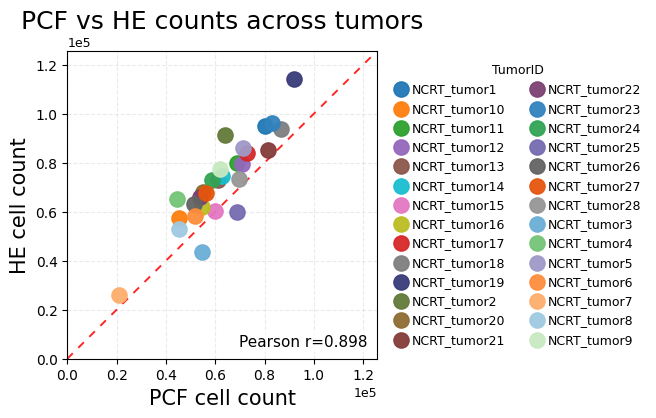

In [ ]:
plot_WSI_counts_cor(merged, fig_size=(4, 4),
                    save_path=None)
                    # save_path=f'{path}Hist2Pheno/data/CODEX/ESCC/{therapy_data}/{save_result}/PCF_HE_counts_correlation.pdf')

### Segment correlation for SA

In [2]:
## All
therapy_data = 'SA'
stardist_coords_path = f'{path}Hist2Pheno/data/CODEX/ESCC/{stardist_data}/{therapy_data}_Float_prob0.01_nms_0.3.csv'
qupath_corner_path = f'{path}Hist2Pheno/data/CODEX/ESCC/{qupath_corner}/{therapy_data}_ROI_Corners.csv'
codex_meta_celltype_path = f'{path}Hist2Pheno/data/CODEX/ESCC/codex_meta_celltype_final.csv'
celltype_pixel_NCRT_path = f'{path}Hist2Pheno/data/CODEX/ESCC/{transfer_data}/{therapy_data}_CellPixCoords_all.csv'
save_path = f'{path}Hist2Pheno/data/CODEX/ESCC/he_cell_coords/{therapy_data}_CellPixCoords_all_StarDist.csv'
save_path4ViT = f'{path}Hist2Pheno/data/CODEX/ESCC/he_cell_coords/{therapy_data}_CellPixCoords_all_StarDist_ViT.csv'

celltype_anno_df, roi_cell_counts, star_coords_in_roi, celltype_pixel_NCRT = make_PCF2HE2StarDist_alignment(
    stardist_coords_path,
    qupath_corner_path,
    codex_meta_celltype_path,
    celltype_pixel_NCRT_path,
    therapy_data=f'{therapy_data}',
    parent_value='all',
    # save_path=save_path,
    # save_path4ViT=save_path4ViT
    save_path=None,
    save_path4ViT=None
)

/home/lingyu/ssd2/Python/Collaborate/esccAI/code/Hist2Pheno_pkg/base.py:3384: FutureWarning: Setting an item of incompatible dtype is deprecated and will raise an error in a future version of pandas. Value 'SA_tumor13' has dtype incompatible with float64, please explicitly cast to a compatible dtype first.
  star_coords.loc[mask, 'TumorID'] = name


Number of rows with TumorID = NaN: 4785
star_coords shape after filtering: (3515738, 4)
     TumorID   centroid_x   centroid_y  probability
0  SA_tumor1  1586.248341  3542.101768     0.898639
1  SA_tumor1  2765.724213  3580.453835     0.892693
2  SA_tumor1  2555.685318  3509.959373     0.890920
3  SA_tumor1  1531.837952  3181.842644     0.890344
4  SA_tumor1  2768.337677  3083.938019     0.888700
Nuclei number within each ROI (sorted by TumorID):
       TumorID  cell_count
24   SA_tumor1       92315
8    SA_tumor2      135738
1    SA_tumor3      180811
16   SA_tumor4      112946
3    SA_tumor5      162048
12   SA_tumor6      126688
2    SA_tumor7      170818
17   SA_tumor8      110550
11   SA_tumor9      127320
27  SA_tumor10       83128
19  SA_tumor11      105584
9   SA_tumor12      135468
21  SA_tumor13      102521
0   SA_tumor14      196223
5   SA_tumor15      142954
6   SA_tumor16      140272
23  SA_tumor17      101751
18  SA_tumor18      107845
20  SA_tumor19      105452
14  SA_tu

ROIs where orange bar (HE: cell_count) is lower than blue bar (PCF: celltype_count):
[]


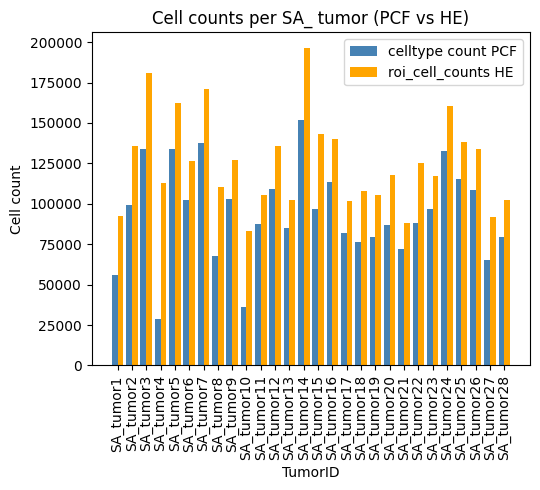

SA_tumor3 - star_coords_in_roi shape: (180811, 4)
SA_tumor3 - celltype_pixel_NCRT shape: (133654, 13)


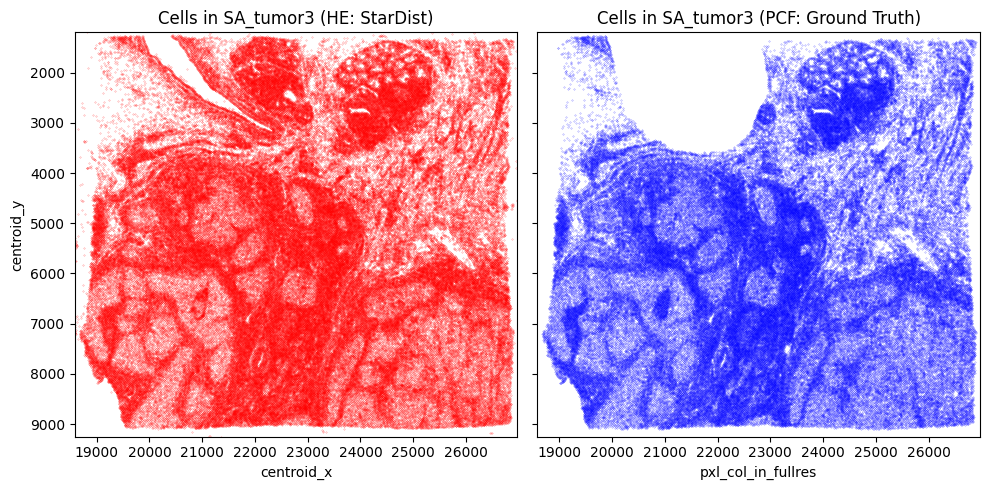

Tumor count used: 28
Pearson r = 0.8868, p = 3.330e-10
Spearman rho = 0.9015, p = 5.970e-11


,TumorID,celltype_count,cell_count
0,SA_tumor1,56244,92315
1,SA_tumor10,35921,83128
2,SA_tumor11,87751,105584
3,SA_tumor12,108961,135468
4,SA_tumor13,84966,102521
5,SA_tumor14,151646,196223
6,SA_tumor15,96507,142954
7,SA_tumor16,113199,140272
8,SA_tumor17,82113,101751
9,SA_tumor18,76616,107845


/home/lingyu/ssd2/Python/Collaborate/esccAI/code/Hist2Pheno_pkg/plot.py:1757: UserWarning: Tight layout not applied. The left and right margins cannot be made large enough to accommodate all Axes decorations.
  plt.tight_layout(rect=(0, 0, 0.80, 1))


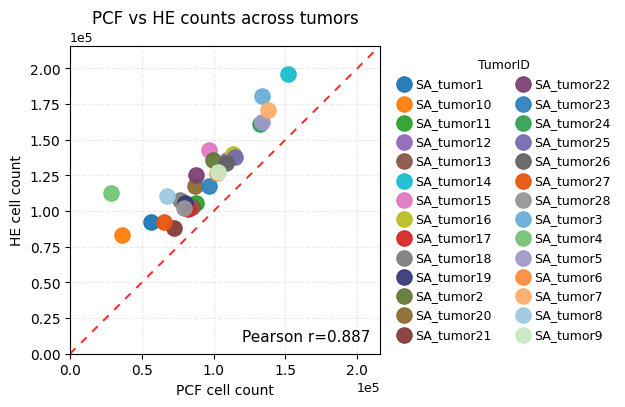

In [3]:
merged = plot_WSI_counts(celltype_anno_df, roi_cell_counts, prefix=f'{therapy_data}_', figure_size=(5.5,5),
# merged = plot_WSI_counts(celltype_anno_df, roi_cell_counts, prefix='SA_', figure_size=(5.5,5),
                         save_path=None)
                        # save_path=f'{path}Hist2Pheno/data/CODEX/ESCC/{therapy_data}/{save_result}/cellcounts_compare_{therapy_data}.pdf')

plot_PCF_HE_counts(star_coords_in_roi, celltype_pixel_NCRT, ROI=f'{therapy_data}_tumor3', figure_size=(10,5),
# plot_PCF_HE_counts(star_coords_in_roi, celltype_pixel_NCRT, ROI='NCRT_tumor3', figure_size=(10,5),
                    save_path=None)
                #    save_path=f'{path}Hist2Pheno/data/CODEX/ESCC/{therapy_data}/{save_result}/cellcounts_compare_tumor3.jpg')

plot_WSI_counts_cor(merged, fig_size=(4, 4),
                    # save_path=None)
                    save_path=f'{path}Hist2Pheno/data/CODEX/ESCC/{therapy_data}/{save_result}/PCF_HE_counts_correlation.pdf')

### Segment correlation for NICT

In [8]:
## All
therapy_data = 'NICT'
stardist_coords_path = f'{path}Hist2Pheno/data/CODEX/ESCC/{stardist_data}/{therapy_data}_Float_prob0.01_nms_0.3.csv'
qupath_corner_path = f'{path}Hist2Pheno/data/CODEX/ESCC/{qupath_corner}/{therapy_data}_ROI_Corners.csv'
codex_meta_celltype_path = f'{path}Hist2Pheno/data/CODEX/ESCC/codex_meta_celltype_final.csv'
celltype_pixel_NCRT_path = f'{path}Hist2Pheno/data/CODEX/ESCC/{transfer_data}/{therapy_data}_CellPixCoords_all.csv'
save_path = f'{path}Hist2Pheno/data/CODEX/ESCC/he_cell_coords/{therapy_data}_CellPixCoords_all_StarDist.csv'
save_path4ViT = f'{path}Hist2Pheno/data/CODEX/ESCC/he_cell_coords/{therapy_data}_CellPixCoords_all_StarDist_ViT.csv'

celltype_anno_df, roi_cell_counts, star_coords_in_roi, celltype_pixel_NCRT = make_PCF2HE2StarDist_alignment(
    stardist_coords_path,
    qupath_corner_path,
    codex_meta_celltype_path,
    celltype_pixel_NCRT_path,
    therapy_data=f'{therapy_data}',
    # therapy_data="SA",
    parent_value='all',
    # save_path=save_path,
    # save_path4ViT=save_path4ViT
    save_path=None,
    save_path4ViT=None
)

/home/lingyu/ssd2/Python/Collaborate/esccAI/code/Hist2Pheno_pkg/base.py:3384: FutureWarning: Setting an item of incompatible dtype is deprecated and will raise an error in a future version of pandas. Value 'NICT_tumor27' has dtype incompatible with float64, please explicitly cast to a compatible dtype first.
  star_coords.loc[mask, 'TumorID'] = name


Number of rows with TumorID = NaN: 1462
star_coords shape after filtering: (2490099, 4)
       TumorID   centroid_x   centroid_y  probability
0  NICT_tumor1  2469.764160  3715.905670     0.887735
1  NICT_tumor1  3100.081322  2144.522308     0.885400
2  NICT_tumor1  2603.857742  2652.212578     0.885325
3  NICT_tumor1  2159.925270  3824.466309     0.885241
4  NICT_tumor1  1694.030411  3709.996391     0.883949
Nuclei number within each ROI (sorted by TumorID):
         TumorID  cell_count
18   NICT_tumor1       79682
3    NICT_tumor2      123189
7    NICT_tumor3      105792
26   NICT_tumor4       50681
19   NICT_tumor5       78415
23   NICT_tumor6       62895
20   NICT_tumor7       71504
17   NICT_tumor8       81137
1    NICT_tumor9      127078
14  NICT_tumor10       90615
9   NICT_tumor11       93885
21  NICT_tumor12       66955
0   NICT_tumor13      144385
22  NICT_tumor14       66464
8   NICT_tumor15       95525
15  NICT_tumor16       88383
4   NICT_tumor17      118152
10  NICT_tumor1

ROIs where orange bar (HE: cell_count) is lower than blue bar (PCF: celltype_count):
[]


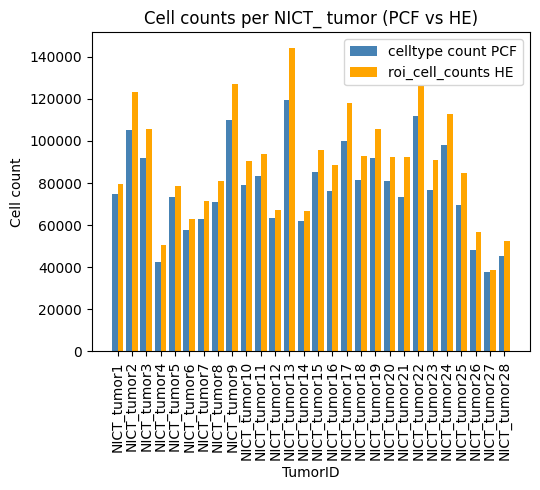

NICT_tumor6 - star_coords_in_roi shape: (62895, 4)
NICT_tumor6 - celltype_pixel_NCRT shape: (57714, 13)


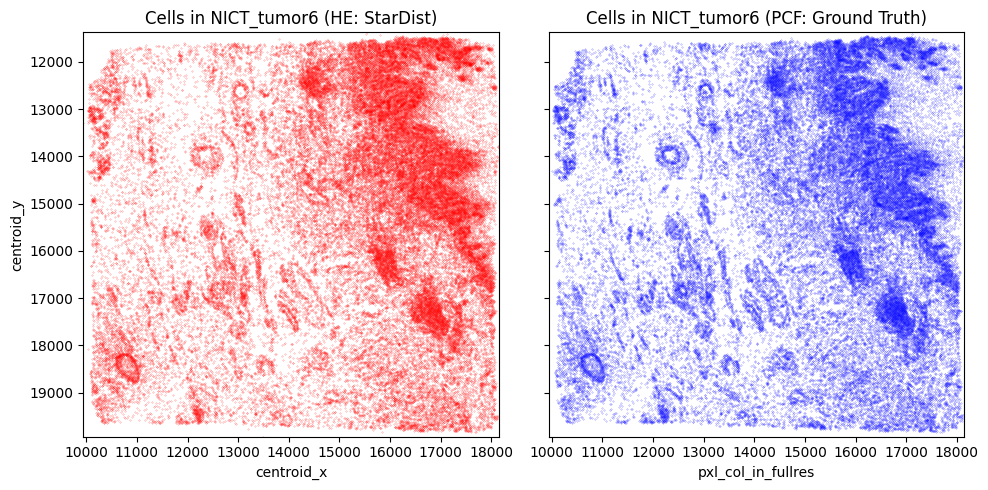

Tumor count used: 28
Pearson r = 0.9911, p = 2.753e-24
Spearman rho = 0.9863, p = 6.936e-22


,TumorID,celltype_count,cell_count
0,NICT_tumor1,74895,79682
1,NICT_tumor10,79125,90615
2,NICT_tumor11,83377,93885
3,NICT_tumor12,63492,66955
4,NICT_tumor13,119651,144385
5,NICT_tumor14,61948,66464
6,NICT_tumor15,85117,95525
7,NICT_tumor16,75982,88383
8,NICT_tumor17,100172,118152
9,NICT_tumor18,81476,92680


/home/lingyu/ssd2/Python/Collaborate/esccAI/code/Hist2Pheno_pkg/plot.py:1757: UserWarning: Tight layout not applied. The left and right margins cannot be made large enough to accommodate all Axes decorations.
  plt.tight_layout(rect=(0, 0, 0.80, 1))


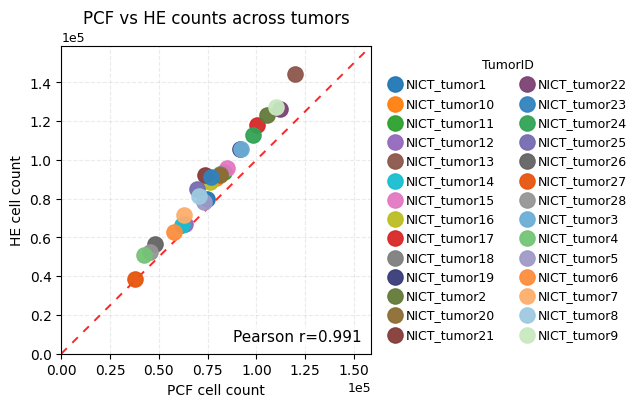

In [9]:
merged = plot_WSI_counts(celltype_anno_df, roi_cell_counts, prefix=f'{therapy_data}_', figure_size=(5.5,5),
                         # save_path=None)
                        save_path=f'{path}Hist2Pheno/data/CODEX/ESCC/{therapy_data}/{save_result}/cellcounts_compare_{therapy_data}.pdf')

plot_PCF_HE_counts(star_coords_in_roi, celltype_pixel_NCRT, ROI=f'{therapy_data}_tumor6', figure_size=(10,5),
                    # save_path=None)
                   save_path=f'{path}Hist2Pheno/data/CODEX/ESCC/{therapy_data}/{save_result}/cellcounts_compare_tumor6.jpg')

plot_WSI_counts_cor(merged, fig_size=(4, 4),
                    # save_path=None)
                    save_path=f'{path}Hist2Pheno/data/CODEX/ESCC/{therapy_data}/{save_result}/PCF_HE_counts_correlation.pdf')

### Segment correlation for NCT

In [6]:
## All
therapy_data = 'NCT'
stardist_coords_path = f'{path}Hist2Pheno/data/CODEX/ESCC/{stardist_data}/{therapy_data}_Float_prob0.01_nms_0.3.csv'
qupath_corner_path = f'{path}Hist2Pheno/data/CODEX/ESCC/{qupath_corner}/{therapy_data}_ROI_Corners.csv'
codex_meta_celltype_path = f'{path}Hist2Pheno/data/CODEX/ESCC/codex_meta_celltype_final.csv'
celltype_pixel_NCRT_path = f'{path}Hist2Pheno/data/CODEX/ESCC/{transfer_data}/{therapy_data}_CellPixCoords_all.csv'
save_path = f'{path}Hist2Pheno/data/CODEX/ESCC/he_cell_coords/{therapy_data}_CellPixCoords_all_StarDist.csv'
save_path4ViT = f'{path}Hist2Pheno/data/CODEX/ESCC/he_cell_coords/{therapy_data}_CellPixCoords_all_StarDist_ViT.csv'

celltype_anno_df, roi_cell_counts, star_coords_in_roi, celltype_pixel_NCRT = make_PCF2HE2StarDist_alignment(
    stardist_coords_path,
    qupath_corner_path,
    codex_meta_celltype_path,
    celltype_pixel_NCRT_path,
    therapy_data=f'{therapy_data}',
    # therapy_data="SA",
    parent_value='all',
    # save_path=save_path,
    # save_path4ViT=save_path4ViT
    save_path=None,
    save_path4ViT=None
)

/home/lingyu/ssd2/Python/Collaborate/esccAI/code/Hist2Pheno_pkg/base.py:3384: FutureWarning: Setting an item of incompatible dtype is deprecated and will raise an error in a future version of pandas. Value 'NCT_tumor4' has dtype incompatible with float64, please explicitly cast to a compatible dtype first.
  star_coords.loc[mask, 'TumorID'] = name


Number of rows with TumorID = NaN: 632
star_coords shape after filtering: (2636690, 4)
      TumorID   centroid_x   centroid_y  probability
0  NCT_tumor1  3909.808601  1616.299946     0.828350
1  NCT_tumor1  3930.289879  1419.968758     0.827442
2  NCT_tumor1  3894.190201  1672.444447     0.816638
3  NCT_tumor1  3926.315033  1397.795315     0.811490
4  NCT_tumor1  3938.150909  1691.868931     0.811202
Nuclei number within each ROI (sorted by TumorID):
        TumorID  cell_count
5    NCT_tumor1      111416
14   NCT_tumor2       87264
3    NCT_tumor3      128824
25   NCT_tumor4       69441
6    NCT_tumor5      107356
4    NCT_tumor6      119908
10   NCT_tumor7      100391
1    NCT_tumor8      134384
19   NCT_tumor9       80151
2   NCT_tumor10      129682
8   NCT_tumor11      105792
23  NCT_tumor12       72077
12  NCT_tumor13       93454
24  NCT_tumor14       70922
22  NCT_tumor15       72261
16  NCT_tumor16       85077
15  NCT_tumor17       85737
27  NCT_tumor18       51623
11  NCT_tumo

ROIs where orange bar (HE: cell_count) is lower than blue bar (PCF: celltype_count):
['NCT_tumor28']


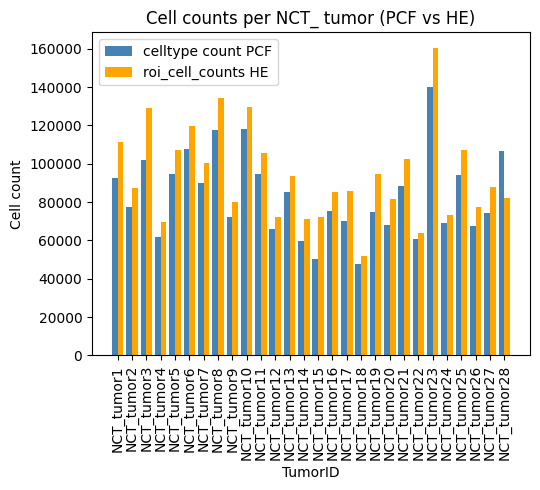

NCT_tumor1 - star_coords_in_roi shape: (111416, 4)
NCT_tumor1 - celltype_pixel_NCRT shape: (92707, 13)


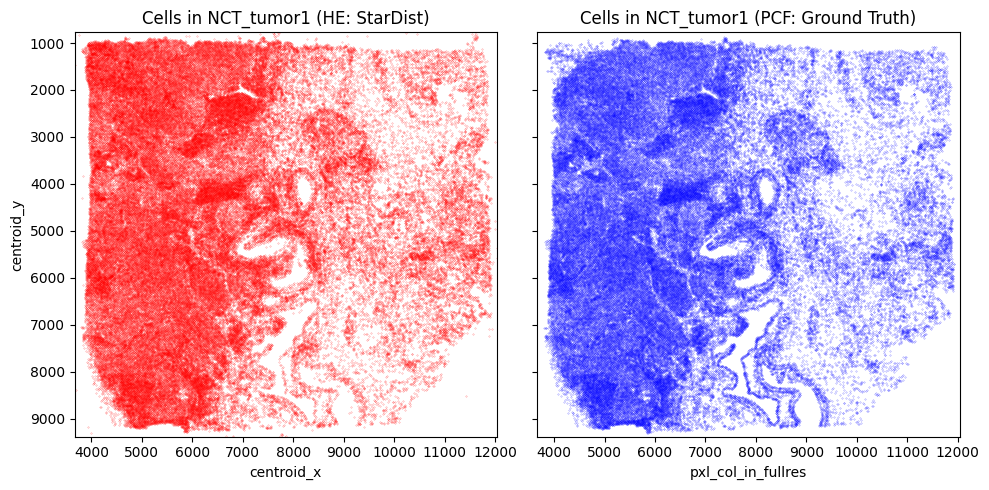

Tumor count used: 28
Pearson r = 0.9322, p = 5.569e-13
Spearman rho = 0.9234, p = 2.583e-12


,TumorID,celltype_count,cell_count
0,NCT_tumor1,92707,111416
1,NCT_tumor10,118260,129682
2,NCT_tumor11,94461,105792
3,NCT_tumor12,65994,72077
4,NCT_tumor13,85483,93454
5,NCT_tumor14,59542,70922
6,NCT_tumor15,50395,72261
7,NCT_tumor16,75499,85077
8,NCT_tumor17,70131,85737
9,NCT_tumor18,47493,51623


/home/lingyu/ssd2/Python/Collaborate/esccAI/code/Hist2Pheno_pkg/plot.py:1757: UserWarning: Tight layout not applied. The left and right margins cannot be made large enough to accommodate all Axes decorations.
  plt.tight_layout(rect=(0, 0, 0.80, 1))


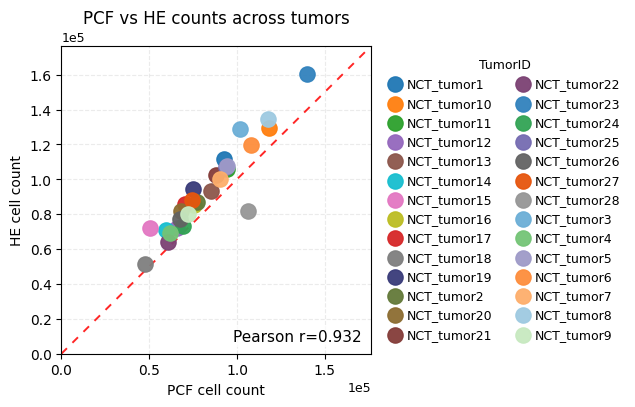

In [7]:
merged = plot_WSI_counts(celltype_anno_df, roi_cell_counts, prefix=f'{therapy_data}_', figure_size=(5.5,5),
# merged = plot_WSI_counts(celltype_anno_df, roi_cell_counts, prefix='SA_', figure_size=(5.5,5),
                         # save_path=None)
                        save_path=f'{path}Hist2Pheno/data/CODEX/ESCC/{therapy_data}/{save_result}/cellcounts_compare_{therapy_data}.pdf')

plot_PCF_HE_counts(star_coords_in_roi, celltype_pixel_NCRT, ROI=f'{therapy_data}_tumor1', figure_size=(10,5),
# plot_PCF_HE_counts(star_coords_in_roi, celltype_pixel_NCRT, ROI='NCRT_tumor3', figure_size=(10,5),
                    # save_path=None)
                   save_path=f'{path}Hist2Pheno/data/CODEX/ESCC/{therapy_data}/{save_result}/cellcounts_compare_tumor1.jpg')

plot_WSI_counts_cor(merged, fig_size=(4, 4),
                    # save_path=None)
                    save_path=f'{path}Hist2Pheno/data/CODEX/ESCC/{therapy_data}/{save_result}/PCF_HE_counts_correlation.pdf')

## Image aligment 

In [2]:
## ROI-specific embedding similarity analysis (tumor1, UNI vs StarDist)
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

# 1) load and read tumor1 ROI corners (2 ROIs)
tumor1_roi = f'{path}Hist2Pheno/data/CODEX/ESCC/{therapy_data}/{segment_data1}/NCRT_tumor1_roi_corners.csv'
tumor1_roi_df = pd.read_csv(tumor1_roi)
print('ROI table:')
display(tumor1_roi_df)

# 2) load embedding npz files
img_embedding = f'{path}Hist2Pheno/data/CODEX/ESCC/{therapy_data}/NCRT_project_tumor1_UNI/matched_features_tumor1_logo.npz'
img_embedding_stardist = f'{path}Hist2Pheno/data/CODEX/ESCC/{therapy_data}/NCRT_project_tumor1_UNI/matched_features_tumor1_stardist.npz'

logo_npz = np.load(img_embedding, allow_pickle=True)
star_npz = np.load(img_embedding_stardist, allow_pickle=True)
print('logo keys:', logo_npz.files)
print('stardist keys:', star_npz.files)

X_logo = logo_npz['X']
C_logo = logo_npz['X_coords']
X_star = star_npz['X']
C_star = star_npz['X_coords']

ROI table:


,Name,TopLeft_X,TopLeft_Y,TopRight_X,TopRight_Y,BottomRight_X,BottomRight_Y,BottomLeft_X,BottomLeft_Y
0,NCRT_tumor1_roi1,11073,2810,12429,2810,12429,4126,11073,4126
1,NCRT_tumor1_roi2,9646,5572,10121,5572,10121,6148,9646,6148


logo keys: ['X', 'y', 'y_level1', 'X_coords', 'groups']
stardist keys: ['X', 'y', 'y_level1', 'X_coords']


ROI cross-source similarity summary (cosine):


,roi,source,logo_cells,stardist_cells,matched_cells,mean_cos,median_cos,p10,p90
0,NCRT_tumor1_roi1,logo_vs_stardist_matched,2238,2237,2237,0.811471,0.84153,0.64526,0.927065
1,NCRT_tumor1_roi2,logo_vs_stardist_matched,864,743,743,0.752588,0.78604,0.53913,0.898904


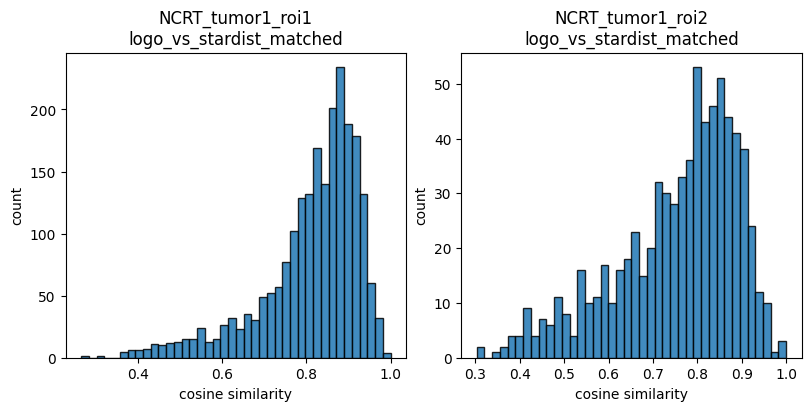

In [3]:
# Continue: ROI-specific comparison (plot only cross-source similarity)

# helper: build ROI bbox from corner columns
def roi_bbox(row):
    x_cols = ['TopLeft_X', 'TopRight_X', 'BottomRight_X', 'BottomLeft_X']
    y_cols = ['TopLeft_Y', 'TopRight_Y', 'BottomRight_Y', 'BottomLeft_Y']
    xs = [float(row[c]) for c in x_cols]
    ys = [float(row[c]) for c in y_cols]
    return min(xs), max(xs), min(ys), max(ys)

# helper: select points in ROI
def roi_mask(coords, bbox):
    x_min, x_max, y_min, y_max = bbox
    x = coords[:, 0]
    y = coords[:, 1]
    return (x >= x_min) & (x <= x_max) & (y >= y_min) & (y <= y_max)

# helper: cross-source similarity on matched coordinates
# use rounded coordinates to match common cells between logo/stardist
def cross_source_similarity(X1, C1, X2, C2, decimals=3):
    k1 = np.round(C1, decimals=decimals)
    k2 = np.round(C2, decimals=decimals)

    m1 = {tuple(k): i for i, k in enumerate(k1)}
    common_i1, common_i2 = [], []
    for j, k in enumerate(k2):
        t = tuple(k)
        if t in m1:
            common_i1.append(m1[t])
            common_i2.append(j)

    if len(common_i1) == 0:
        return {
            'matched': 0,
            'mean': np.nan,
            'median': np.nan,
            'p10': np.nan,
            'p90': np.nan,
            'raw': np.array([]),
        }

    A = X1[np.array(common_i1)].astype(np.float64)
    B = X2[np.array(common_i2)].astype(np.float64)
    A = A / np.clip(np.linalg.norm(A, axis=1, keepdims=True), 1e-12, None)
    B = B / np.clip(np.linalg.norm(B, axis=1, keepdims=True), 1e-12, None)
    cos = np.sum(A * B, axis=1)

    return {
        'matched': len(cos),
        'mean': float(np.mean(cos)),
        'median': float(np.median(cos)),
        'p10': float(np.percentile(cos, 10)),
        'p90': float(np.percentile(cos, 90)),
        'raw': cos,
    }

summary_rows = []
plot_data = []

for _, row in tumor1_roi_df.iterrows():
    roi_name = str(row['Name'])
    bbox = roi_bbox(row)

    m_logo = roi_mask(C_logo, bbox)
    m_star = roi_mask(C_star, bbox)
    X_logo_roi, C_logo_roi = X_logo[m_logo], C_logo[m_logo]
    X_star_roi, C_star_roi = X_star[m_star], C_star[m_star]

    s_cross = cross_source_similarity(X_logo_roi, C_logo_roi, X_star_roi, C_star_roi)

    summary_rows.append(
        {
            'roi': roi_name,
            'source': 'logo_vs_stardist_matched',
            'logo_cells': int(m_logo.sum()),
            'stardist_cells': int(m_star.sum()),
            'matched_cells': s_cross['matched'],
            'mean_cos': s_cross['mean'],
            'median_cos': s_cross['median'],
            'p10': s_cross['p10'],
            'p90': s_cross['p90'],
        }
    )

    if s_cross['matched'] > 0:
        plot_data.append((roi_name, s_cross['raw']))

summary_df = pd.DataFrame(summary_rows)
print('ROI cross-source similarity summary (cosine):')
display(summary_df)

# Plot only cross-source similarity for ROI1 and ROI2
fig, axes = plt.subplots(1, len(plot_data), figsize=(4 * max(1, len(plot_data)), 4), constrained_layout=True)
if len(plot_data) == 1:
    axes = [axes]

for ax, (roi_name, vals) in zip(axes, plot_data):
    ax.hist(vals, bins=40, alpha=0.85, edgecolor='black')
    ax.set_title(f'{roi_name}\nlogo_vs_stardist_matched')
    ax.set_xlabel('cosine similarity')
    ax.set_ylabel('count')

plt.show()